<a href="https://colab.research.google.com/github/luqthewolf-lgtm/Guia-Defijitivo/blob/main/parte1_definitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guia Definitivo -- Parte 1 de 5
## Fundacao: Estatistica + Aprendizado Estatistico + Regressao Linear + Classificacao

**Como usar este notebook:**
- Leia o texto em markdown ANTES de executar o codigo
- Cada linha de codigo tem comentario explicando o que faz e POR QUE
- Resolva as questoes no papel antes de ver o gabarito
- O simbolo [!] marca pegadinhas de prova
- O simbolo [->] marca conexoes com outros modulos

**Prioridade de cada modulo:**
- Modulo 1 (Estatistica): ALTA -- base de tudo, aparece em toda questao
- Modulo 2 (Aprendizado Estatistico): ALTA -- conceitos que sao cobrados diretamente
- Modulo 3 (Regressao Linear): ALTA -- modelo base, metricas, premissas
- Modulo 4 (Classificacao): MUITO ALTA -- tema mais cobrado na prova

---

## Glossario de termos (referencia rapida)

Toda vez que um termo novo aparecer no notebook, ele tambem esta aqui:

| Termo | Definicao simples |
|-------|-------------------|
| H0 | Hipotese nula: suposicao de que nao ha efeito/diferenca |
| H1 | Hipotese alternativa: suposicao de que ha efeito/diferenca |
| P-valor | Probabilidade de ver o resultado SE H0 fosse verdade |
| Alpha | Nivel de significancia: limiar para rejeitar H0 (normalmente 5%) |
| TP | True Positive: previu positivo e era positivo (acerto no positivo) |
| TN | True Negative: previu negativo e era negativo (acerto no negativo) |
| FP | False Positive: previu positivo mas era negativo (alarme falso) |
| FN | False Negative: previu negativo mas era positivo (miss, erro grave) |
| Bias | Erro sistematico: modelo erra sempre na mesma direcao |
| Variancia | Sensibilidade ao dado: modelo muda muito com pequenas mudancas |
| Overfitting | Memorizou o treino mas nao generaliza para dados novos |
| Underfitting | Modelo simples demais, nao captura o padrao real |
| RSS | Residual Sum of Squares: soma dos erros ao quadrado |
| MSE | Mean Squared Error: media dos erros ao quadrado |
| RMSE | Raiz do MSE: erro na mesma unidade de Y |
| MAE | Mean Absolute Error: media dos erros absolutos |
| R^2 | Proporcao da variancia de Y explicada pelo modelo |
| VIF | Variance Inflation Factor: mede multicolinearidade |
| AUC | Area Under the ROC Curve: mede discriminacao do classificador |
| ROC | Receiver Operating Characteristic: curva TPR vs FPR |
| TPR | True Positive Rate = Recall: dos positivos reais, quantos capturei |
| FPR | False Positive Rate: dos negativos reais, quantos marquei errado |


---
# Setup -- Execute Sempre Primeiro

In [ ]:
# Instalacao das dependencias necessarias
!pip install numpy pandas scikit-learn matplotlib seaborn scipy statsmodels --quiet
print("Instalacao concluida!")

Instalacao concluida!


In [ ]:
# ── IMPORTS ──────────────────────────────────────────────────
# Cada biblioteca tem uma funcao especifica:

import numpy as np          # operacoes matematicas e vetoriais
import pandas as pd         # manipulacao de dados em tabelas (DataFrames)
import matplotlib.pyplot as plt  # graficos e visualizacoes
import seaborn as sns       # graficos estatisticos mais bonitos
from scipy import stats     # testes estatisticos e distribuicoes
import warnings, math       # utilitarios
warnings.filterwarnings('ignore')  # suprimir avisos desnecessarios

# Modelos e metricas do sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,      # MSE: erro quadratico medio
    mean_absolute_error,     # MAE: erro absoluto medio
    r2_score,               # R^2: proporcao da variancia explicada
    confusion_matrix,        # matriz TP/TN/FP/FN
    roc_auc_score,          # area sob a curva ROC
    roc_curve,              # curva ROC completa
    precision_recall_curve,  # curva precision vs recall
    f1_score,               # media harmonica de precision e recall
    log_loss                # qualidade das probabilidades
)
from sklearn.preprocessing import StandardScaler  # normalizacao de dados
import statsmodels.api as sm  # inferencia estatistica (p-valores, IC)
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF

# Configuracoes de visualizacao
np.random.seed(42)  # semente para reproducibilidade: mesmos resultados sempre
plt.rcParams.update({
    'figure.figsize': (12, 5),  # tamanho padrao dos graficos
    'axes.grid': True,          # grade de fundo nos graficos
    'grid.alpha': 0.3           # transparencia da grade
})
print("Imports carregados com sucesso!")

Imports carregados com sucesso!


---
# MODULO 1 -- Estatistica Basica
## Prioridade: ALTA | ISLP Capitulos 1 e 13

---

## Por que voce precisa de estatistica?

Imagine que voce e gerente de atendimento no Itau. Um analista chega com um grafico
mostrando que clientes que ligam mais de 3 vezes tem NPS 8% menor. Ele conclui:
"ligar mais de 3 vezes CAUSA queda no NPS -- precisamos limitar as ligacoes!"

Voce sabe estatistica. Voce pergunta: "e os clientes que ligam mais de 3 vezes --
eles ja nao estavam insatisfeitos ANTES de ligar?" Silencio. Essa e a diferenca
entre alguem que usa dado e alguem que entende dado.

Estatistica e a linguagem para fazer perguntas certas sobre dados.

---

## 1A. Tipos de variaveis -- o que voce pode calcular com cada uma

Antes de qualquer analise, identifique o tipo da variavel.
Calcular media de variavel nominal e como calcular a media dos numeros de telefone -- nao faz sentido.

| Tipo | O que e | Exemplo no Itau | Pode calcular |
|------|---------|-----------------|---------------|
| Quantitativa continua | Numero com casas decimais | Volume transacionado, NPS (0-10) | Media, desvio, regressao |
| Quantitativa discreta | Numero inteiro sem decimais | N de ligacoes, N de produtos | Media, contagem |
| Qualitativa nominal | Categoria sem ordem | Segmento (PME/Medio/Large), produto | Moda, contagem, qui-quadrado |
| Qualitativa ordinal | Categoria COM ordem | Rating de credito (A/B/C/D), nivel de risco | Mediana, Spearman |

---

## 1B. Medidas de posicao -- onde os dados estao concentrados

**Media:** soma dividida pelo total. Sensivel a valores extremos.
**Mediana:** valor do meio quando ordenado. Robusta a extremos.
**Moda:** valor que aparece mais vezes.

**Regra de ouro para dados financeiros:**
Quando media >> mediana, ha valores extremos puxando a media para cima.
Use a mediana para representar o "cliente tipico".

Exemplo concreto: faturamento medio das PMEs no Itau pode ser R$500k
(puxado por algumas empresas grandes), mas a mediana e R$80k.
Relatar R$500k como "faturamento tipico" seria enganoso.

---

## 1C. Distribuicoes de probabilidade -- como os dados se comportam

Cada modelo de ML assume uma distribuicao para os dados. Confundir isso e erro grave.

**Normal (Gaussiana):**
- Forma de sino simetrico. A maioria dos valores perto da media.
- Usada em: erros de regressao linear, testes t, intervalos de confianca
- Formula: f(x) = (1/sigma*sqrt(2*pi)) * e^(-(x-mu)^2 / 2*sigma^2)
- [!] PEGADINHA: erros da regressao LOGISTICA nao sao normais -- sao Bernoulli!

**Bernoulli:**
- Resultado binario: 0 ou 1. Um lancamento de moeda.
- Usada em: regressao logistica (Y binario: inadimpliu/nao)
- Formula: P(X=1) = p, P(X=0) = 1-p

**Poisson:**
- Contagem de eventos em intervalo fixo. Sempre inteiro >= 0.
- Usada em: numero de transacoes por dia, chamadas na central por hora
- Formula: P(X=k) = (lambda^k * e^-lambda) / k!

**Log-normal:**
- Logaritmo da variavel e normal. Sempre positivo, assimetrico a direita.
- Usada em: volume financeiro, renda, valor de contratos
- Por que: renda nao pode ser negativa, e assimetrica (muitos ganham pouco, poucos ganham muito)


In [ ]:
# ── 1.1 TIPOS DE VARIAVEIS E ESTATISTICAS DESCRITIVAS ────────────────────────

# Criando um dataset simulado de clientes PJ do Itau
# Cada linha e um cliente, cada coluna e uma caracteristica
np.random.seed(42)  # garante que os dados sao os mesmos toda vez que rodar
n = 600  # numero de clientes simulados

dados = pd.DataFrame({
    # Quantitativa continua: pode ter casas decimais
    'nps_nota': np.random.choice(
        range(0, 11), n,               # notas de 0 a 10
        p=[0.02,0.02,0.03,0.04,0.05,   # probabilidade de cada nota
           0.06,0.08,0.10,0.15,0.20,0.25]  # mais clientes dao notas altas
    ),
    # Quantitativa continua: log-normal porque volume nao pode ser negativo
    'volume_transac': np.random.lognormal(mean=8, sigma=1.5, size=n),
    # Quantitativa discreta: numero inteiro de ligacoes
    'n_ligacoes': np.random.poisson(lam=2.5, size=n),
    # Quantitativa continua: tempo em minutos
    'tempo_espera_min': np.random.exponential(scale=8, size=n).clip(0),
    # Qualitativa nominal: segmento sem ordem natural
    'segmento': np.random.choice(
        ['PME', 'Medio', 'Large'],
        size=n,
        p=[0.60, 0.30, 0.10]  # 60% PME, 30% medio, 10% large
    ),
})

# Criando a categoria de NPS (ordinal: Detrator < Neutro < Promotor)
# Regra padrao da metodologia NPS:
# 0-6: Detrator | 7-8: Neutro | 9-10: Promotor
dados['categoria_nps'] = dados['nps_nota'].apply(
    lambda nota: 'Detrator' if nota <= 6 else ('Neutro' if nota <= 8 else 'Promotor')
)

# Estatisticas descritivas das variaveis quantitativas
print("=== ESTATISTICAS DESCRITIVAS ===")
print()
# .describe() calcula automaticamente: count, mean, std, min, quartis, max
print(dados[['nps_nota', 'volume_transac', 'n_ligacoes', 'tempo_espera_min']].describe().round(2))
print()

# Frequencia das variaveis qualitativas
print("Distribuicao por segmento:")
# normalize=True converte contagens em proporcoes (0 a 1)
print(dados['segmento'].value_counts(normalize=True).round(3))
print()
print("Distribuicao NPS:")
print(dados['categoria_nps'].value_counts())

=== ESTATISTICAS DESCRITIVAS ===

       nps_nota  volume_transac  n_ligacoes  tempo_espera_min
count    600.00          600.00      600.00            600.00
mean       7.34         9550.08        2.50              7.85
std        2.72        21412.00        1.59              7.98
min        0.00           52.18        0.00              0.01
25%        6.00         1220.59        1.00              2.16
50%        8.00         3149.35        2.00              5.05
75%       10.00         8054.42        3.00             11.34
max       10.00       302041.96        7.00             61.79

Distribuicao por segmento:
segmento
PME      0.618
Medio    0.298
Large    0.083
Name: proportion, dtype: float64

Distribuicao NPS:
categoria_nps
Promotor    277
Detrator    181
Neutro      142
Name: count, dtype: int64


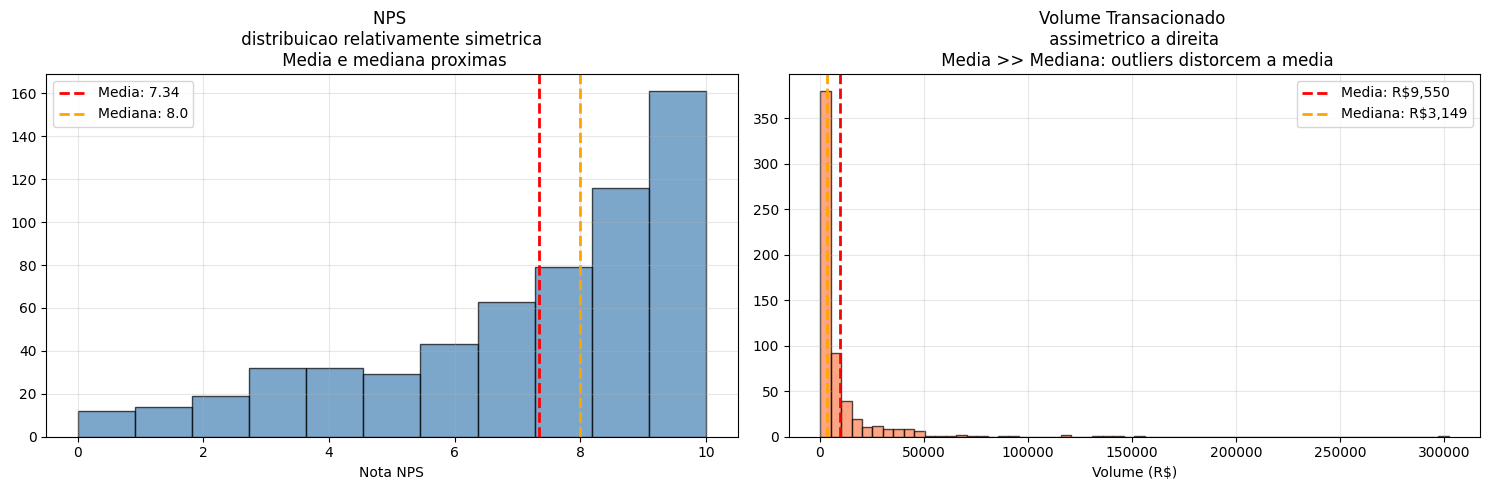

Volume transacionado:
  Media:   R$       9,550  <- distorcida por clientes grandes
  Mediana: R$       3,149  <- representa melhor o cliente tipico
  Razao media/mediana: 3.0x

[!] REGRA: sempre verifique se media >> mediana antes de relatar.
    Em dados financeiros (renda, volume, contratos): use MEDIANA.
    Para o diretor: 'o cliente tipico transaciona R$X' -- use mediana.


In [ ]:
# ── 1.2 MEDIA vs MEDIANA: IMPACTO DOS OUTLIERS ────────────────────────────────

# Este grafico ilustra o problema de usar media em dados financeiros
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Grafico 1: NPS (distribuicao mais simetrica) ──────────────────────────────
axes[0].hist(
    dados['nps_nota'],
    bins=11,            # um bin por nota (0 a 10)
    edgecolor='black',
    color='steelblue',
    alpha=0.7
)
# Linha vertical na media
axes[0].axvline(
    dados['nps_nota'].mean(),
    color='red', linestyle='--', linewidth=2,
    label=f"Media: {dados['nps_nota'].mean():.2f}"
)
# Linha vertical na mediana
axes[0].axvline(
    dados['nps_nota'].median(),
    color='orange', linestyle='--', linewidth=2,
    label=f"Mediana: {dados['nps_nota'].median():.1f}"
)
axes[0].set_title('NPS \n distribuicao relativamente simetrica \n Media e mediana proximas')
axes[0].set_xlabel('Nota NPS')
axes[0].legend()

# ── Grafico 2: Volume (distribuicao assimetrica -- tipico dado financeiro) ─────
axes[1].hist(
    dados['volume_transac'],
    bins=60,            # mais bins para capturar a cauda longa
    edgecolor='black',
    color='coral',
    alpha=0.7
)
axes[1].axvline(
    dados['volume_transac'].mean(),
    color='red', linestyle='--', linewidth=2,
    label=f"Media: R${dados['volume_transac'].mean():,.0f}"
)
axes[1].axvline(
    dados['volume_transac'].median(),
    color='orange', linestyle='--', linewidth=2,
    label=f"Mediana: R${dados['volume_transac'].median():,.0f}"
)
axes[1].set_title('Volume Transacionado \n assimetrico a direita \n Media >> Mediana: outliers distorcem a media')
axes[1].set_xlabel('Volume (R$)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Quantificando a diferenca
media_vol = dados['volume_transac'].mean()
mediana_vol = dados['volume_transac'].median()
print(f"Volume transacionado:")
print(f"  Media:   R${media_vol:>12,.0f}  <- distorcida por clientes grandes")
print(f"  Mediana: R${mediana_vol:>12,.0f}  <- representa melhor o cliente tipico")
print(f"  Razao media/mediana: {media_vol/mediana_vol:.1f}x")
print()
print("[!] REGRA: sempre verifique se media >> mediana antes de relatar.")
print("    Em dados financeiros (renda, volume, contratos): use MEDIANA.")
print("    Para o diretor: 'o cliente tipico transaciona R$X' -- use mediana.")

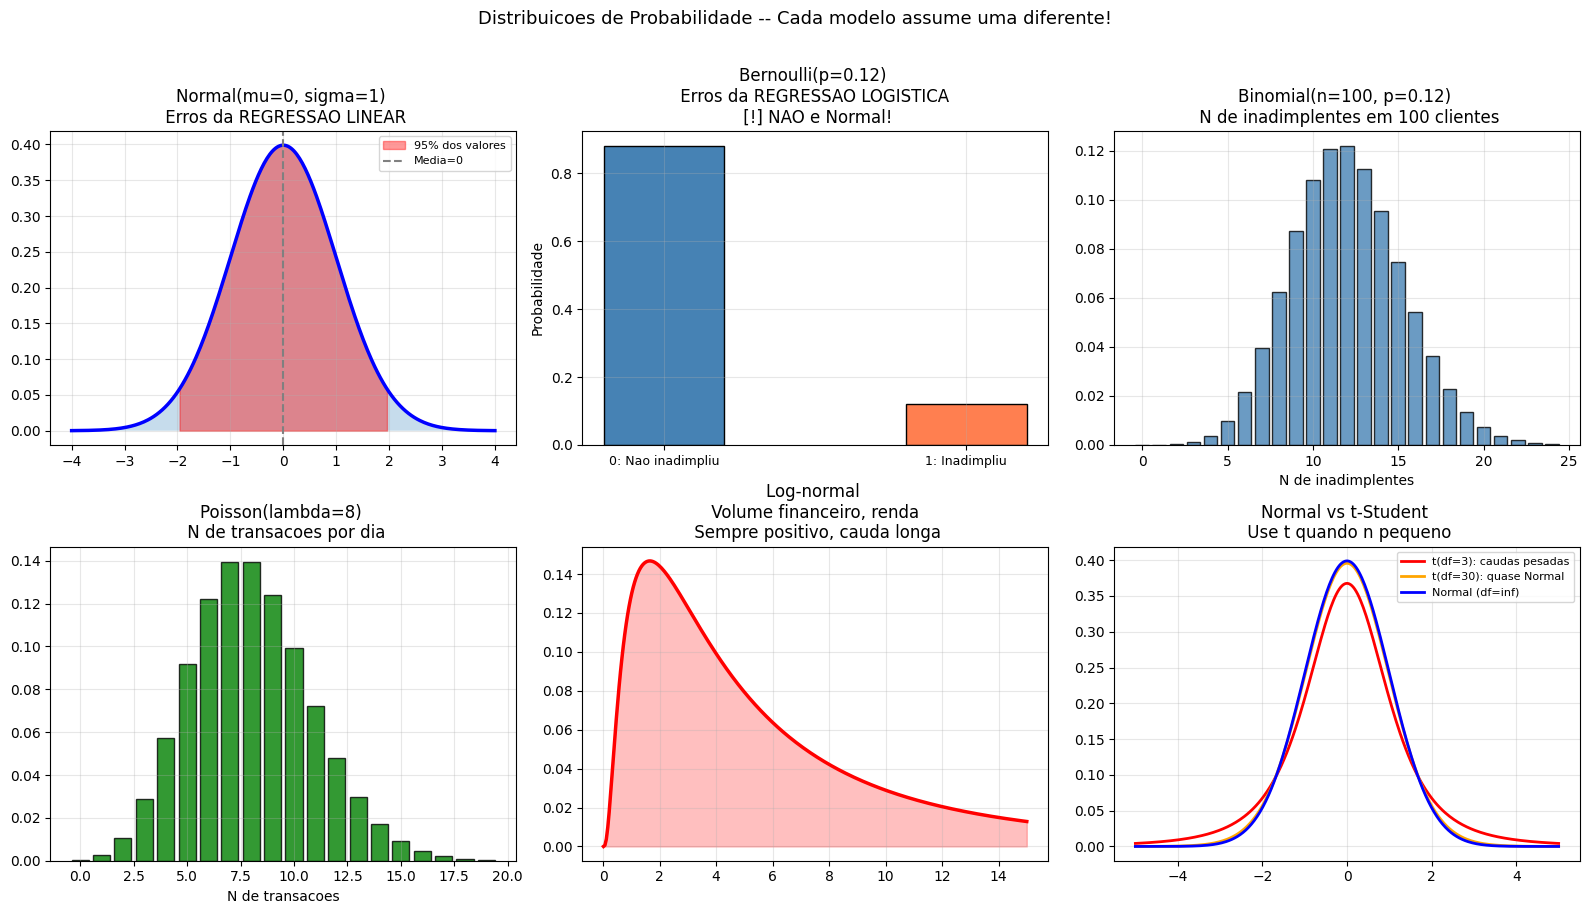

[!] QUAL DISTRIBUICAO CADA MODELO ASSUME:
  Regressao Linear:    epsilon ~ Normal(0, sigma^2)  [erros sao normais]
  Regressao Logistica: Y ~ Bernoulli(p)              [resultado e 0 ou 1]
  Contagem de eventos: Y ~ Poisson(lambda)           [inteiro >= 0]
  Volume financeiro:   Y ~ Log-normal                [sempre positivo]

[!] PEGADINHA DE PROVA (Q12 da prova real):
  'Erros da logistica devem ser normais' -> FALSO
  Logistica assume BERNOULLI, nao Normal


In [ ]:
# ── 1.3 DISTRIBUICOES DE PROBABILIDADE ────────────────────────────────────────

# Visualizando as 4 principais distribuicoes e quando cada uma aparece
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── Normal: erros de regressao linear ─────────────────────────────────────────
x_normal = np.linspace(-4, 4, 300)  # 300 pontos de -4 a +4

axes[0,0].plot(
    x_normal,
    stats.norm.pdf(x_normal, loc=0, scale=1),  # pdf = funcao de densidade
    'b-', linewidth=2.5
)
axes[0,0].fill_between(x_normal, stats.norm.pdf(x_normal), alpha=0.25)
# Marcando a area de 95% (entre -1.96 e +1.96 desvios padrao)
x_95 = np.linspace(-1.96, 1.96, 200)
axes[0,0].fill_between(x_95, stats.norm.pdf(x_95), alpha=0.4, color='red',
                        label='95% dos valores')
axes[0,0].axvline(0, color='gray', linestyle='--', label='Media=0')
axes[0,0].set_title('Normal(mu=0, sigma=1) \n Erros da REGRESSAO LINEAR')
axes[0,0].legend(fontsize=8)

# ── Bernoulli: resultado binario ──────────────────────────────────────────────
p_inadim = 0.12  # 12% de inadimplencia
axes[0,1].bar(
    [0, 1],
    [1-p_inadim, p_inadim],  # prob de nao inadimplir e de inadimplir
    color=['steelblue', 'coral'],
    edgecolor='black',
    width=0.4
)
axes[0,1].set_xticks([0, 1])
axes[0,1].set_xticklabels(['0: Nao inadimpliu', '1: Inadimpliu'], fontsize=9)
axes[0,1].set_ylabel('Probabilidade')
axes[0,1].set_title(f'Bernoulli(p={p_inadim}) \n Erros da REGRESSAO LOGISTICA \n [!] NAO e Normal!')

# ── Binomial: contagem de sucesso em n tentativas ─────────────────────────────
k_vals = np.arange(0, 25)  # de 0 a 24 inadimplentes
n_clientes, p = 100, 0.12   # em 100 clientes com p=12%
axes[0,2].bar(
    k_vals,
    stats.binom.pmf(k_vals, n_clientes, p),  # probabilidade de cada quantidade
    color='steelblue', edgecolor='black', alpha=0.8
)
axes[0,2].set_title(f'Binomial(n={n_clientes}, p={p}) \n N de inadimplentes em {n_clientes} clientes')
axes[0,2].set_xlabel('N de inadimplentes')

# ── Poisson: contagem de eventos em intervalo fixo ────────────────────────────
lambda_transac = 8  # media de 8 transacoes por dia
k_transac = np.arange(0, 20)
axes[1,0].bar(
    k_transac,
    stats.poisson.pmf(k_transac, lambda_transac),
    color='green', edgecolor='black', alpha=0.8
)
axes[1,0].set_title(f'Poisson(lambda={lambda_transac}) \n N de transacoes por dia')
axes[1,0].set_xlabel('N de transacoes')

# ── Log-normal: volume financeiro ─────────────────────────────────────────────
x_lognorm = np.linspace(0.01, 15, 300)
axes[1,1].plot(
    x_lognorm,
    stats.lognorm.pdf(x_lognorm, s=1, scale=np.exp(1.5)),
    'r-', linewidth=2.5
)
axes[1,1].fill_between(x_lognorm,
    stats.lognorm.pdf(x_lognorm, s=1, scale=np.exp(1.5)),
    alpha=0.25, color='red'
)
axes[1,1].set_title('Log-normal \n Volume financeiro, renda \n Sempre positivo, cauda longa')

# ── Normal vs t-Student: amostras pequenas ────────────────────────────────────
x_t = np.linspace(-5, 5, 300)
# t-Student com poucos graus de liberdade tem caudas mais pesadas que Normal
for df, cor, label in [(3, 'red', 't(df=3): caudas pesadas'),
                        (30, 'orange', 't(df=30): quase Normal'),
                        (1000, 'blue', 'Normal (df=inf)')]:
    if df < 1000:
        axes[1,2].plot(x_t, stats.t.pdf(x_t, df=df), color=cor, lw=2, label=label)
    else:
        axes[1,2].plot(x_t, stats.norm.pdf(x_t), color=cor, lw=2, label=label)
axes[1,2].set_title('Normal vs t-Student \n Use t quando n pequeno')
axes[1,2].legend(fontsize=8)

plt.suptitle('Distribuicoes de Probabilidade -- Cada modelo assume uma diferente!',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("[!] QUAL DISTRIBUICAO CADA MODELO ASSUME:")
print("  Regressao Linear:    epsilon ~ Normal(0, sigma^2)  [erros sao normais]")
print("  Regressao Logistica: Y ~ Bernoulli(p)              [resultado e 0 ou 1]")
print("  Contagem de eventos: Y ~ Poisson(lambda)           [inteiro >= 0]")
print("  Volume financeiro:   Y ~ Log-normal                [sempre positivo]")
print()
print("[!] PEGADINHA DE PROVA (Q12 da prova real):")
print("  'Erros da logistica devem ser normais' -> FALSO")
print("  Logistica assume BERNOULLI, nao Normal")

In [ ]:
# ── 1.4 TESTES DE HIPOTESE: A LOGICA COMPLETA ────────────────────────────────

# Analogia do cotidiano para entender o raciocinio:
#
# Voce acusa um colega de usar dados viciados (sempre da cara).
# H0 (hipotese nula): a moeda e honesta (50% de cara)
# H1 (hipotese alternativa): a moeda e viciada (mais de 50% de cara)
#
# Ele joga 20 vezes e da cara 16 vezes (80%).
# P-valor: se a moeda fosse honesta, qual a probabilidade de dar >= 16 caras em 20 jogadas?
# Se essa probabilidade for muito baixa (< 5%), rejeitamos a hipotese de moeda honesta.

print("=== ANALOGIA DO TESTE DE HIPOTESE ===")
print()
# Calculando o p-valor da moeda: P(X >= 16 | n=20, p=0.5)
from scipy.stats import binom as binom_dist

# P de dar 16 ou mais caras se a moeda fosse honesta
p_valor_moeda = 1 - binom_dist.cdf(15, n=20, p=0.5)
print(f"Moeda jogada 20 vezes, resultado: 16 caras")
print(f"H0: moeda honesta (p=0.5)")
print(f"P-valor: {p_valor_moeda:.4f}")
print(f"Interpretacao: se a moeda fosse honesta, isso aconteceria em {p_valor_moeda*100:.1f}% das vezes")
print(f"Com alpha=5%: {'REJEITAMOS H0 -- evidencia de moeda viciada' if p_valor_moeda < 0.05 else 'Nao rejeitamos H0'}")
print()

# Agora aplicando ao contexto bancario:
# Nova regua de atendimento melhorou o NPS?
np.random.seed(42)
nps_antes  = np.random.normal(loc=7.2, scale=1.5, size=200)  # NPS antes da mudanca
nps_depois = np.random.normal(loc=7.6, scale=1.4, size=200)  # NPS depois da mudanca

# Teste t de Student para comparar duas medias
t_stat, p_valor = stats.ttest_ind(nps_depois, nps_antes)

print("=== TESTE A/B: nova regua de atendimento melhorou o NPS? ===")
print()
print("H0: media_depois = media_antes  [a regua nao teve efeito]")
print("H1: media_depois != media_antes [a regua teve efeito]")
print()
print(f"Media NPS antes:  {nps_antes.mean():.4f}")
print(f"Media NPS depois: {nps_depois.mean():.4f}")
print(f"Diferenca:        {nps_depois.mean() - nps_antes.mean():+.4f} pontos")
print()
print(f"Estatistica t: {t_stat:.4f}")
print(f"P-valor:        {p_valor:.4f}")
print()

alpha = 0.05  # nivel de significancia padrao de 5%
if p_valor < alpha:
    print(f"p={p_valor:.4f} < alpha={alpha}")
    print("REJEITAMOS H0 -- ha evidencia de que a regua melhorou o NPS")
else:
    print(f"p={p_valor:.4f} >= alpha={alpha}")
    print("NAO rejeitamos H0 -- sem evidencia suficiente de melhora")

# Intervalo de confianca da diferenca
diff = nps_depois.mean() - nps_antes.mean()
# Erro padrao da diferenca entre duas medias
se = np.sqrt(nps_depois.var(ddof=1)/len(nps_depois) + nps_antes.var(ddof=1)/len(nps_antes))
ic_95 = (diff - 1.96*se, diff + 1.96*se)  # 1.96 = quantil 97.5% da Normal
print()
print(f"IC 95% da diferenca: [{ic_95[0]:.4f}, {ic_95[1]:.4f}] pontos de NPS")
print("Interpretacao: se repetissemos o estudo 100 vezes com amostras diferentes,")
print("95 dos 100 ICs construidos conteriam a diferenca real entre os grupos")

=== ANALOGIA DO TESTE DE HIPOTESE ===

Moeda jogada 20 vezes, resultado: 16 caras
H0: moeda honesta (p=0.5)
P-valor: 0.0059
Interpretacao: se a moeda fosse honesta, isso aconteceria em 0.6% das vezes
Com alpha=5%: REJEITAMOS H0 -- evidencia de moeda viciada

=== TESTE A/B: nova regua de atendimento melhorou o NPS? ===

H0: media_depois = media_antes  [a regua nao teve efeito]
H1: media_depois != media_antes [a regua teve efeito]

Media NPS antes:  7.1388
Media NPS depois: 7.7202
Diferenca:        +0.5814 pontos

Estatistica t: 4.1850
P-valor:        0.0000

p=0.0000 < alpha=0.05
REJEITAMOS H0 -- ha evidencia de que a regua melhorou o NPS

IC 95% da diferenca: [0.3091, 0.8537] pontos de NPS
Interpretacao: se repetissemos o estudo 100 vezes com amostras diferentes,
95 dos 100 ICs construidos conteriam a diferenca real entre os grupos


=== ERROS TIPO 1 E TIPO 2 -- TABELA COMPLETA ===

                    H0 e VERDADEIRA     H0 e FALSA
Rejeitar H0:        ERRO TIPO 1         CORRETO (poder)
                    (falso positivo)     (verdadeiro positivo)
Nao rejeitar H0:    CORRETO             ERRO TIPO 2
                    (verdadeiro neg.)    (falso negativo)

Contexto 1: Deteccao de fraude em Pix
  Erro Tipo 1: Erro Tipo 1 (FP): bloqueia transacao legitima (cliente irritado)
  Erro Tipo 2: Erro Tipo 2 (FN): fraude PASSA DESPERCEBIDA
  Mais grave:  TIPO 2 -- prejuizo financeiro direto e irreversivel

Contexto 2: Aprovacao de credito
  Erro Tipo 1: Erro Tipo 1 (FP): nega credito para bom pagador (perde cliente)
  Erro Tipo 2: Erro Tipo 2 (FN): aprova mau pagador (inadimplencia)
  Mais grave:  Depende do custo relativo de cada erro

Contexto 3: Campanha de marketing de produto
  Erro Tipo 1: Erro Tipo 1 (FP): declara vitoria quando e ruido estatistico
  Erro Tipo 2: Erro Tipo 2 (FN): nao detecta que campanha funciona
 

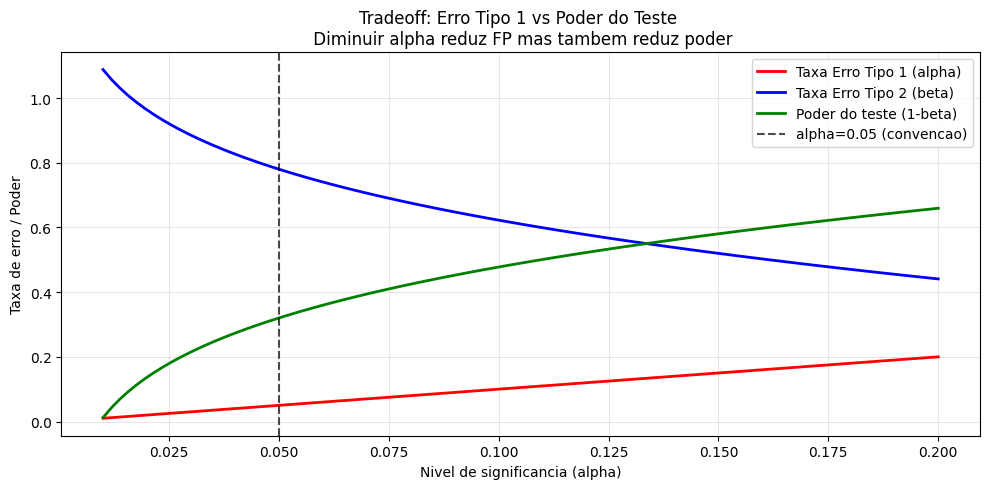

In [ ]:
# ── 1.5 ERROS TIPO 1 e TIPO 2 ────────────────────────────────────────────────

# ANALOGIA: tribunal de justica
# H0: o reu e inocente (suposicao padrao do sistema)
# H1: o reu e culpado
#
# Erro Tipo 1 (falso positivo): condenar inocente
#   -> Ocorre quando rejeitamos H0 sendo ela verdadeira
#   -> Taxa de erro tipo 1 = alpha (definido por voce)
#
# Erro Tipo 2 (falso negativo): absolver culpado
#   -> Ocorre quando nao rejeitamos H0 sendo ela falsa
#   -> Taxa de erro tipo 2 = beta
#   -> Poder do teste = 1 - beta (probabilidade de detectar efeito real)

print("=== ERROS TIPO 1 E TIPO 2 -- TABELA COMPLETA ===")
print()
print("                    H0 e VERDADEIRA     H0 e FALSA")
print("Rejeitar H0:        ERRO TIPO 1         CORRETO (poder)")
print("                    (falso positivo)     (verdadeiro positivo)")
print("Nao rejeitar H0:    CORRETO             ERRO TIPO 2")
print("                    (verdadeiro neg.)    (falso negativo)")
print()

# Contexto bancario: qual erro e mais grave?
contextos = [
    ("Deteccao de fraude em Pix",
     "Erro Tipo 2 (FN): fraude PASSA DESPERCEBIDA",
     "Erro Tipo 1 (FP): bloqueia transacao legitima (cliente irritado)",
     "TIPO 2 -- prejuizo financeiro direto e irreversivel"),
    ("Aprovacao de credito",
     "Erro Tipo 2 (FN): aprova mau pagador (inadimplencia)",
     "Erro Tipo 1 (FP): nega credito para bom pagador (perde cliente)",
     "Depende do custo relativo de cada erro"),
    ("Campanha de marketing de produto",
     "Erro Tipo 2 (FN): nao detecta que campanha funciona",
     "Erro Tipo 1 (FP): declara vitoria quando e ruido estatistico",
     "TIPO 1 -- investimento desnecessario"),
]

for i, (contexto, erro_t2, erro_t1, mais_grave) in enumerate(contextos, 1):
    print(f"Contexto {i}: {contexto}")
    print(f"  Erro Tipo 1: {erro_t1}")
    print(f"  Erro Tipo 2: {erro_t2}")
    print(f"  Mais grave:  {mais_grave}")
    print()

# Visualizando o tradeoff entre alfa e poder
alphas_vec = np.linspace(0.01, 0.20, 100)
# Poder aumenta quando alpha aumenta (aceita mais risco de erro tipo 1)
# Formula simplificada para ilustracao pedagogica
poder_vec = 1 - stats.norm.ppf(1 - alphas_vec/2) * 0.5 + 0.3

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas_vec, alphas_vec, 'r-', lw=2, label='Taxa Erro Tipo 1 (alpha)')
ax.plot(alphas_vec, 1-poder_vec+0.1, 'b-', lw=2, label='Taxa Erro Tipo 2 (beta)')
ax.plot(alphas_vec, poder_vec, 'g-', lw=2, label='Poder do teste (1-beta)')
ax.axvline(0.05, color='black', linestyle='--', alpha=0.7, label='alpha=0.05 (convencao)')
ax.set_xlabel('Nivel de significancia (alpha)')
ax.set_ylabel('Taxa de erro / Poder')
ax.set_title('Tradeoff: Erro Tipo 1 vs Poder do Teste \n Diminuir alpha reduz FP mas tambem reduz poder')
ax.legend()
plt.tight_layout()
plt.show()

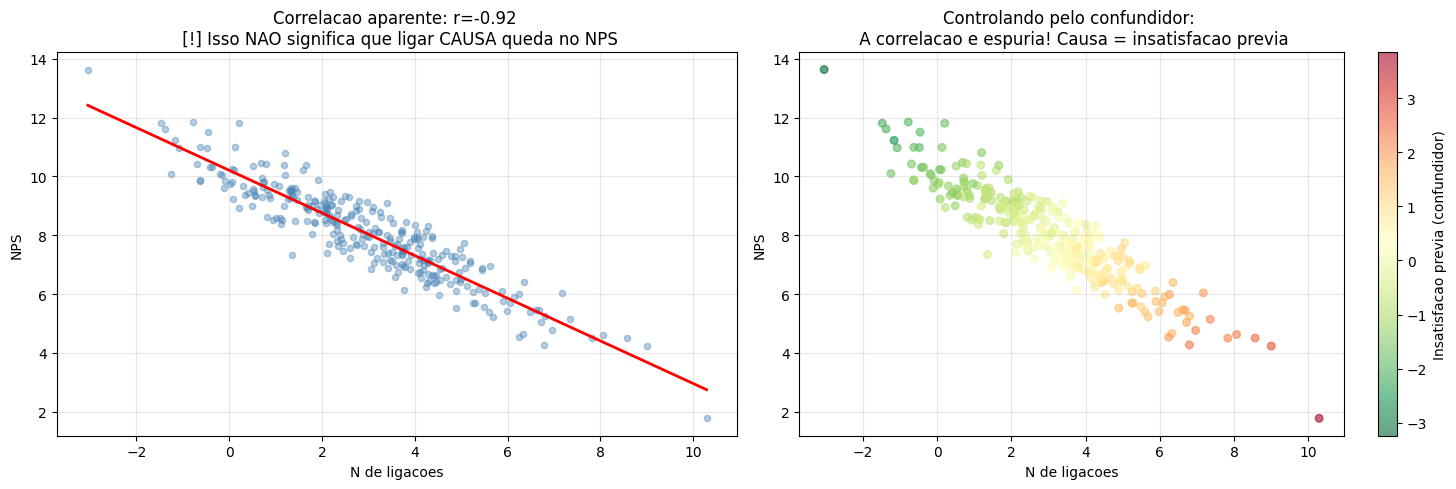

CORRELACAO vs CAUSALIDADE:
  Correlacao observada: r=-0.92 (forte!)
  Mas a CAUSA real de ambas e a insatisfacao previa

[->] Para CAUSALIDADE, voce precisa de:
  1. Experimento aleatorio (A/B test): randomizacao controla confundidores
  2. Diferencas em Diferencas (DiD): usa dados antes/depois com controle
  3. Regressao Descontinua (RDD): explora threshold como quasi-experimento
  4. Variaveis instrumentais: usa variavel que afeta X mas nao Y diretamente

[!] PEARSON vs SPEARMAN:
  Pearson: mede correlacao LINEAR. Formula: r = cov(X,Y)/(sigma_X*sigma_Y)
  Spearman: mede correlacao MONOTONICA (usa postos/ranks)
  Use Spearman quando: dados ordinais, relacao nao-linear, outliers presentes


In [ ]:
# ── 1.6 CORRELACAO vs CAUSALIDADE ────────────────────────────────────────────

# ANALOGIA: o caso do sorvete e os afogamentos
# Toda vez que as vendas de sorvete aumentam, os afogamentos tambem aumentam.
# Correlacao altissima! Mas sorvete NAO CAUSA afogamento.
# O confundidor e o CALOR: calor -> mais pessoas na praia -> mais afogamentos
#                                    calor -> mais sede -> mais sorvete
#
# No banco: numero de ligacoes e NPS tem correlacao negativa.
# Isso significa que ligar causa queda no NPS?
# OU clientes insatisfeitos ja ligam mais E dao NPS menor?

np.random.seed(42)
n = 300

# Simulando o confundidor: "insatisfacao previa"
insatisfacao_previa = np.random.normal(0, 1, n)  # variavel oculta

# Ambas as variaveis sao causadas pela insatisfacao previa
n_ligacoes_sim = 3 + 2*insatisfacao_previa + np.random.normal(0, 0.5, n)
nps_sim        = 8 - 1.5*insatisfacao_previa + np.random.normal(0, 0.5, n)

# Correlacao observada
corr_obs, pval_obs = stats.pearsonr(n_ligacoes_sim, nps_sim)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: correlacao aparente (sem mostrar o confundidor)
axes[0].scatter(n_ligacoes_sim, nps_sim, alpha=0.4, s=20, color='steelblue')
# Linha de regressao
m, b = np.polyfit(n_ligacoes_sim, nps_sim, 1)
x_line = np.linspace(n_ligacoes_sim.min(), n_ligacoes_sim.max(), 100)
axes[0].plot(x_line, m*x_line+b, 'r-', lw=2)
axes[0].set_xlabel('N de ligacoes')
axes[0].set_ylabel('NPS')
axes[0].set_title(f'Correlacao aparente: r={corr_obs:.2f} \n [!] Isso NAO significa que ligar CAUSA queda no NPS')

# Grafico 2: colorindo pelo confundidor -- fica claro que e espurio
sc = axes[1].scatter(n_ligacoes_sim, nps_sim,
    c=insatisfacao_previa, cmap='RdYlGn_r', alpha=0.6, s=30)
plt.colorbar(sc, ax=axes[1], label='Insatisfacao previa (confundidor)')
axes[1].set_xlabel('N de ligacoes')
axes[1].set_ylabel('NPS')
axes[1].set_title('Controlando pelo confundidor: \n A correlacao e espuria! Causa = insatisfacao previa')

plt.tight_layout()
plt.show()

print("CORRELACAO vs CAUSALIDADE:")
print(f"  Correlacao observada: r={corr_obs:.2f} (forte!)")
print(f"  Mas a CAUSA real de ambas e a insatisfacao previa")
print()
print("[->] Para CAUSALIDADE, voce precisa de:")
print("  1. Experimento aleatorio (A/B test): randomizacao controla confundidores")
print("  2. Diferencas em Diferencas (DiD): usa dados antes/depois com controle")
print("  3. Regressao Descontinua (RDD): explora threshold como quasi-experimento")
print("  4. Variaveis instrumentais: usa variavel que afeta X mas nao Y diretamente")
print()
print("[!] PEARSON vs SPEARMAN:")
print("  Pearson: mede correlacao LINEAR. Formula: r = cov(X,Y)/(sigma_X*sigma_Y)")
print("  Spearman: mede correlacao MONOTONICA (usa postos/ranks)")
print("  Use Spearman quando: dados ordinais, relacao nao-linear, outliers presentes")

In [ ]:
# ── QUESTOES DO MODULO 1 (escolhidas como professor) ──────────────────────────

print("=" * 68)
print("QUESTOES DO MODULO 1")
print("Professor escolheu estas 3 por cobrarem raciocinio, nao decoreba")
print("=" * 68)
print("""
QUESTAO 1 (conceitual -- nivel prova Itau):
  Um modelo de deteccao de fraude tem p-valor = 0.04 para o coeficiente
  de 'valor_transacao'. Seu gestor diz: "otimo, ha 96% de chance de que
  valor da transacao realmente afete a chance de fraude."

  Ele esta certo? Explique o erro se houver.

QUESTAO 2 (aplicacao -- nivel entrevista):
  Voce analisa dados de clientes PJ e descobre:
  - Clientes que usam o app tem NPS medio = 8.2
  - Clientes que nao usam o app tem NPS medio = 6.9

  Seu diretor quer lanar uma campanha forcando todos a usarem o app
  para aumentar o NPS. O que voce diria a ele?

QUESTAO 3 (calculo -- nivel prova Itau):
  Volume medio de transacoes = R$2.3M, mediana = R$400k.
  N de clientes = 500.

  (a) O que a diferenca entre media e mediana indica?
  (b) Para relatar o 'cliente tipico' ao conselho, qual metrica usar?
  (c) Se voce remover os 5 maiores clientes, o que acontece com
      a media? E com a mediana?
""")

print("GABARITOS:")
print("""
Q1: NAO, o gestor esta ERRADO.
    Definicao correta de p-valor:
    P-valor = probabilidade de observar um resultado tao extremo quanto o observado,
    ASSUMINDO que H0 e verdadeira (coeficiente = 0).

    P-valor de 0.04 significa: se o coeficiente fosse zero, veriamos esse
    resultado apenas 4% das vezes por puro acaso.

    NAO significa: ha 96% de chance do efeito ser real.
    O p-valor nao e a probabilidade de H0 ser verdadeira ou falsa --
    e a probabilidade do DADO dado H0 (nao o contrario!).
    [Erro classico e recorrente em provas]

Q2: Voce diria que correlacao nao e causalidade.
    O problema e o confundidor: clientes mais engajados (jovens, digitais,
    mais satisfeitos de base) TANTO usam o app QUANTO dao NPS mais alto.
    Forcar o uso do app pode aumentar NPS ou pode irritar clientes que
    nao querem usar o app -- dependendo do perfil.

    Para responder a questao causalmente, voce precisaria de um experimento:
    sortear aleatoriamente quem recebe incentivo para usar o app e medir o NPS.

    Recomendacao: propor um A/B test antes de escalar a campanha.

Q3: (a) Media >> Mediana (5.75x maior!) indica forte assimetria a direita.
    Poucos clientes com volume muito alto estao puxando a media para cima.
    A distribuicao e log-normal tipica de dados financeiros.

    (b) MEDIANA (R$400k) -- representa o cliente tipico.
    A media (R$2.3M) e distorcida pelos grandes e nao representa bem a maioria.

    (c) Media: cairia dramaticamente -- os 5 maiores sao responsaveis por
    boa parte da soma total (provavelmente 40-60% do volume).
    Mediana: mudaria pouco ou nada -- ela depende so do valor central,
    nao dos extremos. Com 500 clientes, remover 5 do topo nao muda quem
    fica no meio da fila.
""")

QUESTOES DO MODULO 1
Professor escolheu estas 3 por cobrarem raciocinio, nao decoreba

QUESTAO 1 (conceitual -- nivel prova Itau):
  Um modelo de deteccao de fraude tem p-valor = 0.04 para o coeficiente
  de 'valor_transacao'. Seu gestor diz: "otimo, ha 96% de chance de que
  valor da transacao realmente afete a chance de fraude."

  Ele esta certo? Explique o erro se houver.

QUESTAO 2 (aplicacao -- nivel entrevista):
  Voce analisa dados de clientes PJ e descobre:
  - Clientes que usam o app tem NPS medio = 8.2
  - Clientes que nao usam o app tem NPS medio = 6.9

  Seu diretor quer lanar uma campanha forcando todos a usarem o app
  para aumentar o NPS. O que voce diria a ele?

QUESTAO 3 (calculo -- nivel prova Itau):
  Volume medio de transacoes = R$2.3M, mediana = R$400k.
  N de clientes = 500.

  (a) O que a diferenca entre media e mediana indica?
  (b) Para relatar o 'cliente tipico' ao conselho, qual metrica usar?
  (c) Se voce remover os 5 maiores clientes, o que acontece com
  

---
# MODULO 2 -- Aprendizado Estatistico
## Prioridade: ALTA | ISLP Capitulo 2

---

## O que e aprendizado estatistico?

Imagine que voce e o responsavel por credito de uma carteira de 50.000 CNPJs.
Voce precisa decidir: aprovar ou negar credito para cada um.

Voce tem informacoes de cada empresa: faturamento, setor, tempo de relacionamento,
historico de pagamento, numero de funcionarios. E tem o historico de quais
empresas inadimpliram no passado.

**Aprendizado estatistico e o conjunto de ferramentas para encontrar padroes
nesses dados e usar esses padroes para tomar decisoes melhores.**

O problema central: dado X (as informacoes que voce tem), prever Y (vai inadimplir?).

---

## 2A. A equacao fundamental

```
Y = f(X) + epsilon
```

Cada simbolo tem significado preciso:

**Y** -- o que voce quer prever
- Exemplo: nota de NPS (0-10), probabilidade de inadimplencia (0 ou 1)
- Pode ser continuo (regressao) ou categorico (classificacao)

**X** -- as variaveis que voce observa e usa para prever
- Exemplo: tempo de conta, volume transacionado, segmento, n de produtos
- Tambem chamado de features, variaveis preditoras, covariadas

**f(X)** -- a relacao sistematica entre X e Y
- E o que o modelo aprende dos dados historicos
- Nunca observamos f diretamente -- estimamos ela com base nos dados

**epsilon** -- o erro irredutivel
- A parte de Y que nenhum modelo consegue prever
- Representa: variabilidade aleatoria, fatores que voce nao observa,
  humor do respondente do NPS, eventos externos imprevistos
- [!] CRITICO: define o TETO de qualquer modelo. Mesmo o modelo perfeito
  erra por causa do epsilon.

---

## 2B. Por que estimamos f? Duas razoes com consequencias diferentes

**PREDICAO:** voce quer prever Y com a maior precisao possivel.
Nao importa muito como f funciona internamente -- quer o output.
Exemplo: score de credito para cada CNPJ. O modelo pode ser caixa preta.

**INFERENCIA:** voce quer entender COMO X afeta Y.
Precisa de modelo interpretavel com coeficientes significativos.
Exemplo: "qual fator mais influencia o NPS?" O modelo precisa ser explicavel.

[!] ERRO COMUM: usar modelo de predicao (XGBoost) para fazer inferencia.
XGBoost tem AUC de 0.85 mas nao te diz o efeito causal de cada variavel.

---

## 2C. Bias-Variance Tradeoff -- o conceito mais importante do capitulo

```
Erro esperado = Bias^2 + Variancia + Variancia do epsilon (irredutivel)
```

**Analogia do aluno:**

**Bias alto (underfitting):** aluno que decora so o resumo de 2 paginas.
Na prova, erra sistematicamente porque nao aprendeu o suficiente.
Erra as questoes faceis E as dificeis. Previsivel no erro.

**Variancia alta (overfitting):** aluno que decora todas as provas antigas.
Se cair a mesma questao, acerta. Se mudar um detalhe, erra completamente.
Muito sensivel ao material de treino especifico.

**Equilibrio:** aluno que entende o conceito.
Acerta questoes novas porque aprendeu o padrao, nao a resposta especifica.

---

## 2D. Parametrico vs Nao-parametrico -- uma decisao de design

**Parametrico:** voce assume uma forma para f antes de ver os dados.
Exemplo: "vou assumir que a relacao e linear." Depois estima os parametros.
Precisa de menos dado, mais interpretavel, mas pode estar errado na forma.
Modelos: Regressao Linear, Logistica, Ridge, Lasso.

**Nao-parametrico:** voce nao assume forma. Os dados definem f.
Mais flexivel, captura relacoes complexas, mas precisa de muito mais dado
e tende a overfittar mais facilmente.
Modelos: KNN, Random Forest, Redes Neurais.

---

## 2E. Supervisionado vs Nao-Supervisionado -- fronteira critica

[!] Esta fronteira cai em toda prova. Aprenda uma vez e nunca mais erre.

**Supervisionado: TEM Y (rotulo)**
- Voce sabe a resposta certa para cada exemplo de treino
- O modelo aprende a mapear X -> Y
- Exemplos: regressao (Y continuo), classificacao (Y categorico)
- Casos Itau: prever inadimplencia, NPS, churn, probabilidade de aceite

**Nao-supervisionado: SEM Y (sem rotulo)**
- Voce so tem X. Nao ha resposta certa.
- O modelo descobre estrutura nos dados sem supervisao
- Exemplos: clustering (K-means), reducao de dimensionalidade (PCA)
- Casos Itau: segmentar CNPJs por comportamento, comprimir variaveis

[!] CLUSTERING E SEMPRE NAO-SUPERVISIONADO.
Se voce usa rotulos, e classificacao (supervisionado), nao clustering.


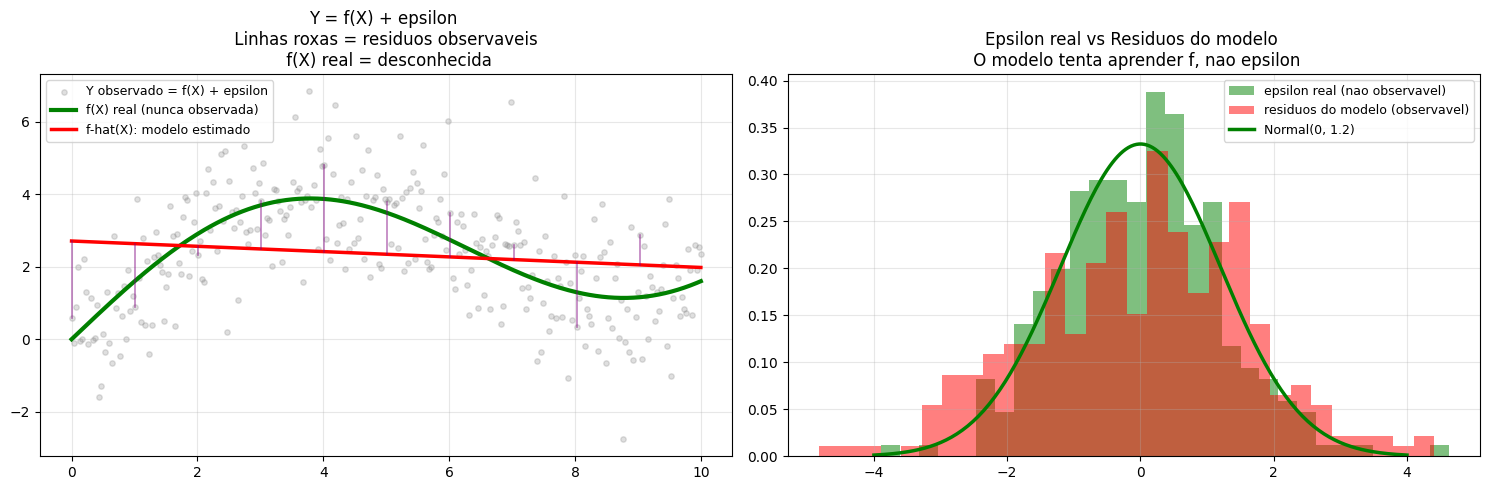

Sigma do epsilon real:     1.200
Std dos residuos do modelo:1.605

[!] O modelo NAO pode ter MSE menor que epsilon^2 = Var(epsilon)
    Teto teorico de MSE: 1.440
    MSE do modelo:       2.577

[->] Isso conecta com a formula:
     Erro esperado = Bias^2 + Variancia + Var(epsilon)
     Var(epsilon) e irredutivel -- nenhum modelo passa desse teto


In [ ]:
# ── 2.1 VISUALIZANDO Y = f(X) + epsilon ──────────────────────────────────────

np.random.seed(42)

# Criando a funcao real f(X) que nao observamos diretamente
X_true = np.linspace(0, 10, 300)

# f(X) = relacao real entre X e Y
# Neste caso: Y aumenta com X mas de forma nao-linear (seno + linear)
f_real = lambda x: 2.5*np.sin(x/2) + 0.4*x

# Y observado = f(X) + epsilon (ruido irredutivel)
epsilon_sigma = 1.2   # desvio padrao do erro irredutivel
epsilon_obs   = np.random.normal(0, epsilon_sigma, 300)
Y_obs         = f_real(X_true) + epsilon_obs

# Ajustando um modelo de regressao linear (modelo simples, parametrico)
X_reshape = X_true.reshape(-1, 1)  # sklearn precisa de array 2D
modelo_linear = LinearRegression().fit(X_reshape, Y_obs)
Y_hat = modelo_linear.predict(X_reshape)  # previsoes do modelo

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Grafico 1: Y = f(X) + epsilon ─────────────────────────────────────────────
axes[0].scatter(X_true, Y_obs, alpha=0.25, s=15, color='gray',
                label='Y observado = f(X) + epsilon')
axes[0].plot(X_true, f_real(X_true), 'g-', lw=3,
             label='f(X) real (nunca observada)')
axes[0].plot(X_true, Y_hat, 'r-', lw=2.5,
             label='f-hat(X): modelo estimado')
# Mostrando alguns residuos (distancia entre Y_obs e Y_hat)
for i in range(0, 300, 30):
    axes[0].plot([X_true[i], X_true[i]], [Y_obs[i], Y_hat[i]],
                 'purple', alpha=0.5, lw=1.2)
axes[0].set_title('Y = f(X) + epsilon \n Linhas roxas = residuos observaveis \n f(X) real = desconhecida')
axes[0].legend(fontsize=9)

# ── Grafico 2: distribuicao dos erros irredutíveis ────────────────────────────
residuos = Y_obs - Y_hat
axes[1].hist(epsilon_obs, bins=30, alpha=0.5, color='green',
             density=True, label='epsilon real (nao observavel)')
axes[1].hist(residuos, bins=30, alpha=0.5, color='red',
             density=True, label='residuos do modelo (observavel)')
# Curva normal teorica
x_norm = np.linspace(-4, 4, 200)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, 0, epsilon_sigma),
             'g-', lw=2.5, label=f'Normal(0, {epsilon_sigma})')
axes[1].set_title('Epsilon real vs Residuos do modelo \n O modelo tenta aprender f, nao epsilon')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Sigma do epsilon real:     {epsilon_sigma:.3f}")
print(f"Std dos residuos do modelo:{np.std(residuos):.3f}")
print()
print("[!] O modelo NAO pode ter MSE menor que epsilon^2 = Var(epsilon)")
print(f"    Teto teorico de MSE: {epsilon_sigma**2:.3f}")
print(f"    MSE do modelo:       {mean_squared_error(Y_obs, Y_hat):.3f}")
print()
print("[->] Isso conecta com a formula:")
print("     Erro esperado = Bias^2 + Variancia + Var(epsilon)")
print("     Var(epsilon) e irredutivel -- nenhum modelo passa desse teto")

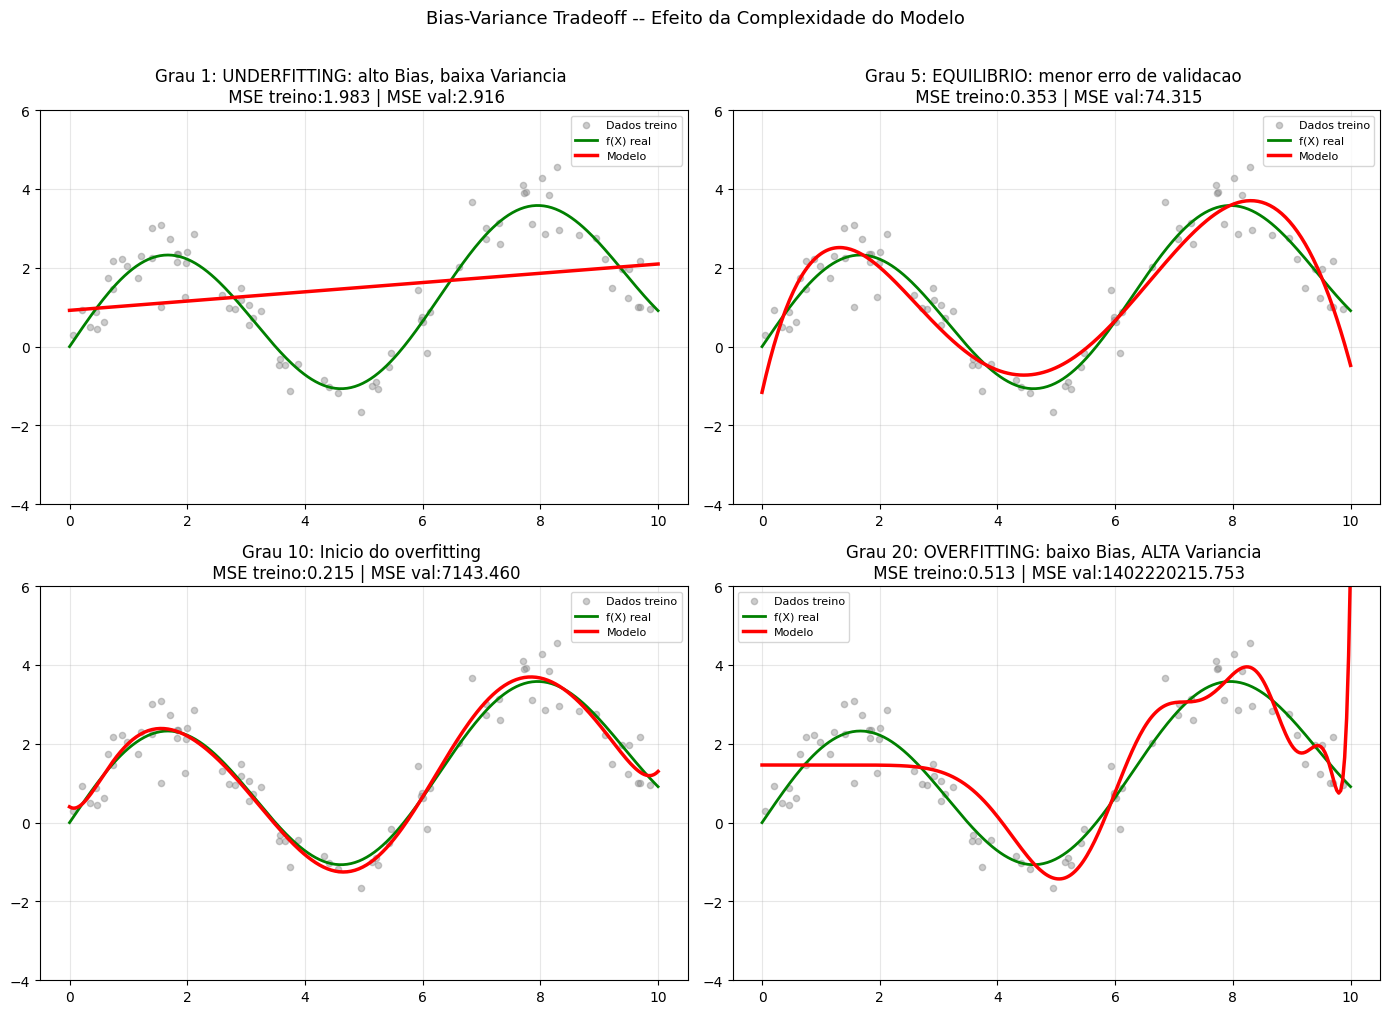

INTERPRETACAO:
 Grau |   MSE Treino |    MSE Val | Diagnostico
-----------------------------------------------------------------
    1 |       1.9833 |     2.9158 | Bias alto -- modelo nao captura o padrao
    5 |       0.3526 |    74.3148 | Equilibrio -- melhor ponto
   10 |       0.2153 |  7143.4597 | Variancia subindo -- inicio do overfit
   20 |       0.5132 | 1402220215.7527 | Variancia alta -- memorizando ruido

[!] DIAGNOSTICO PRATICO:
    Se MSE treino << MSE val: OVERFITTING (variancia alta)
    Se MSE treino ~= MSE val mas ambos altos: UNDERFITTING (bias alto)
    Se MSE treino ~= MSE val e ambos baixos: EQUILIBRIO


In [ ]:
# ── 2.2 BIAS-VARIANCE TRADEOFF: VISUALIZACAO COMPLETA ────────────────────────

np.random.seed(42)

# Dados com relacao nao-linear (seno)
n_pts = 80
X_bv  = np.sort(np.random.uniform(0, 10, n_pts)).reshape(-1, 1)
y_bv  = np.sin(X_bv.ravel()) * 2 + 0.2*X_bv.ravel() + np.random.normal(0, 0.5, n_pts)
X_plot= np.linspace(0, 10, 300).reshape(-1, 1)  # pontos para visualizar o modelo

# Funcao real (o que queremos aprender)
f_real_bv = lambda x: np.sin(x)*2 + 0.2*x

# Testando 4 graus de complexidade
graus = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

kf_bv = KFold(n_splits=5, shuffle=False)  # CV para estimar MSE de validacao

for ax, grau in zip(axes.ravel(), graus):
    # Criando pipeline: polinomial features + regressao linear
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.pipeline import make_pipeline

    pipe = make_pipeline(
        PolynomialFeatures(degree=grau),  # transforma X em [1, X, X^2, ..., X^grau]
        LinearRegression()
    )
    pipe.fit(X_bv, y_bv)  # treina no dado completo

    # MSE no treino (otimista)
    mse_treino = mean_squared_error(y_bv, pipe.predict(X_bv))
    # MSE na validacao via CV (realista -- estima generalizacao)
    res_cv = cross_validate(pipe, X_bv, y_bv, cv=kf_bv,
                            scoring='neg_mean_squared_error')
    mse_val = -res_cv['test_score'].mean()  # negativo porque sklearn usa neg_

    # Previsoes do modelo para o plot
    y_pred_plot = pipe.predict(X_plot)

    # Plot dos dados e do modelo
    ax.scatter(X_bv, y_bv, alpha=0.4, s=20, color='gray', label='Dados treino')
    ax.plot(X_plot, f_real_bv(X_plot.ravel()), 'g-', lw=2, label='f(X) real')
    ax.plot(X_plot, y_pred_plot, 'r-', lw=2.5, label='Modelo')
    ax.set_ylim(-4, 6)

    # Diagnostico baseado nos MSEs
    if grau == 1:   diagnostico = "UNDERFITTING: alto Bias, baixa Variancia"
    elif grau == 5: diagnostico = "EQUILIBRIO: menor erro de validacao"
    elif grau == 10: diagnostico = "Inicio do overfitting"
    else:           diagnostico = "OVERFITTING: baixo Bias, ALTA Variancia"

    ax.set_title(f'Grau {grau}: {diagnostico} \n MSE treino:{mse_treino:.3f} | MSE val:{mse_val:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Bias-Variance Tradeoff -- Efeito da Complexidade do Modelo',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("INTERPRETACAO:")
print(f"{'Grau':>5} | {'MSE Treino':>12} | {'MSE Val':>10} | Diagnostico")
print("-"*65)
for grau in graus:
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.pipeline import make_pipeline
    pipe = make_pipeline(PolynomialFeatures(grau), LinearRegression())
    pipe.fit(X_bv, y_bv)
    mse_tr = mean_squared_error(y_bv, pipe.predict(X_bv))
    mse_va = -cross_validate(pipe, X_bv, y_bv, cv=kf_bv,
                              scoring='neg_mean_squared_error')['test_score'].mean()
    if grau == 1:   diag = "Bias alto -- modelo nao captura o padrao"
    elif grau == 5: diag = "Equilibrio -- melhor ponto"
    elif grau == 10: diag = "Variancia subindo -- inicio do overfit"
    else:           diag = "Variancia alta -- memorizando ruido"
    print(f"{grau:>5} | {mse_tr:>12.4f} | {mse_va:>10.4f} | {diag}")

print()
print("[!] DIAGNOSTICO PRATICO:")
print("    Se MSE treino << MSE val: OVERFITTING (variancia alta)")
print("    Se MSE treino ~= MSE val mas ambos altos: UNDERFITTING (bias alto)")
print("    Se MSE treino ~= MSE val e ambos baixos: EQUILIBRIO")

In [ ]:
# ── QUESTOES DO MODULO 2 ──────────────────────────────────────────────────────

print("=" * 68)
print("QUESTOES DO MODULO 2")
print("=" * 68)
print("""
QUESTAO 1 (conceitual):
  Voce treinou um XGBoost para prever inadimplencia.
  AUC no treino = 0.97. AUC na validacao = 0.68.

  (a) Qual e o diagnostico?
  (b) O que voce faria para corrigir?
  (c) Como voce distingue overfitting de data leakage?

QUESTAO 2 (aplicacao):
  Seu gestor quer saber: 'O que CAUSA inadimplencia nos nossos CNPJs?'
  Voce deve escolher entre XGBoost (AUC=0.87) ou Regressao Logistica (AUC=0.81).

  Qual voce escolhe e por que?

QUESTAO 3 (conceitual):
  Existe um teto para a qualidade de qualquer modelo de ML.
  O que define esse teto? Como voce sabe quando chegou nele?
""")

print("GABARITOS:")
print("""
Q1:
  (a) OVERFITTING: modelo memorizou os dados de treino.
      AUC de treino excelente mas cai drasticamente na validacao.
      O modelo aprendeu o ruido dos dados, nao o padrao real.

  (b) Correcoes possiveis:
      - Reduzir complexidade: max_depth menor (4-6 em vez de 10+)
      - Adicionar regularizacao: reg_lambda, reg_alpha no XGBoost
      - Usar early stopping: para de adicionar arvores quando val para de melhorar
      - Coletar mais dados de treino
      - Feature selection: remover variaveis com ruido

  (c) Distinguindo overfitting de data leakage:
      Overfitting: treino bom, val ruim, mas degrada gradualmente em dados novos.
      Leakage: performance perfeita no treino E collapsa em producao.
      Teste: avaliar em janela temporal futura. Leakage colapsa completamente.
      Verificar feature importance: alguma variavel domina inexplicavelmente?
      Ex: 'status_final_do_contrato' vazando informacao do futuro.

Q2: Regressao Logistica.
    A pergunta e de INFERENCIA (entender causas), nao predicao.
    Logistica tem coeficientes interpretaveis com p-valores e intervalos de confianca.
    Voce pode dizer: 'atraso > 30 dias aumenta as odds de inadimplencia em 2.8x'.
    XGBoost e caixa-preta -- excelente para predicao, ruim para explicar causas.
    No contexto de credito do Itau, o BACEN pode exigir explicabilidade.

Q3: O teto e a VARIANCIA DO ERRO IRREDUTIVEL (Var(epsilon)).
    E a parte de Y que nao pode ser explicada por nenhuma variavel X disponivel.
    Inclui: variabilidade aleatoria, fatores nao observados, erros de medicao.

    Como saber quando chegou:
    - MSE do modelo se aproxima de Var(epsilon) estimado
    - Aumentar a complexidade do modelo nao reduz mais o MSE de validacao
    - Cross-validation mostra que o gap entre treino e val e minimo
    - Modelos muito diferentes chegam ao mesmo MSE de validacao
""")

QUESTOES DO MODULO 2

QUESTAO 1 (conceitual):
  Voce treinou um XGBoost para prever inadimplencia.
  AUC no treino = 0.97. AUC na validacao = 0.68.

  (a) Qual e o diagnostico?
  (b) O que voce faria para corrigir?
  (c) Como voce distingue overfitting de data leakage?

QUESTAO 2 (aplicacao):
  Seu gestor quer saber: 'O que CAUSA inadimplencia nos nossos CNPJs?'
  Voce deve escolher entre XGBoost (AUC=0.87) ou Regressao Logistica (AUC=0.81).

  Qual voce escolhe e por que?

QUESTAO 3 (conceitual):
  Existe um teto para a qualidade de qualquer modelo de ML.
  O que define esse teto? Como voce sabe quando chegou nele?

GABARITOS:

Q1:
  (a) OVERFITTING: modelo memorizou os dados de treino.
      AUC de treino excelente mas cai drasticamente na validacao.
      O modelo aprendeu o ruido dos dados, nao o padrao real.

  (b) Correcoes possiveis:
      - Reduzir complexidade: max_depth menor (4-6 em vez de 10+)
      - Adicionar regularizacao: reg_lambda, reg_alpha no XGBoost
      - Usar ea

---
# MODULO 3 -- Regressao Linear
## Prioridade: ALTA | ISLP Capitulo 3

---

## Por que comecar com regressao linear?

A regressao linear parece simples, mas e a base de TUDO.
Regressao logistica e uma extensao da linear.
Ridge e Lasso sao regressoes lineares com penalidade.
Redes neurais sem ativacao nao-linear sao regressoes lineares.
PCA usa algebra linear. SVM usa hiperplanos lineares.

Se voce entender regressao linear profundamente, os outros modelos ficam mais faceis.

---

## 3A. A equacao e o que cada parte significa

```
Y = beta_0 + beta_1*X1 + beta_2*X2 + ... + beta_p*Xp + epsilon
```

**beta_0 (intercepto):** valor de Y quando TODOS os X sao zero.
Nem sempre tem interpretacao pratica. Se X1=tempo_conta e X2=volume,
beta_0 seria o NPS de um cliente com 0 anos de conta e R$0 de volume -- abstrato.

**beta_j (coeficiente de Xj):** quanto Y muda em media para cada unidade de Xj,
**MANTENDO TODOS OS OUTROS X CONSTANTES.**
Esta ultima parte e CRITICA e o que a prova mais cobra.

Exemplo: beta_tempo_resolucao = -0.15 significa:
"Cada minuto a mais de tempo de resolucao reduz o NPS em 0.15 pontos,
mantendo tempo de espera, numero de contatos e nivel de credito constantes."

**epsilon:** o erro. Parte de Y que o modelo nao captura.

---

## 3B. Como os coeficientes sao estimados (OLS -- Ordinary Least Squares)

O metodo dos minimos quadrados ordinarios minimiza a soma dos erros ao quadrado:

```
RSS = sum( (yi - beta_0 - beta_1*xi1 - ... - beta_p*xip)^2 )
```

A solucao analitica (formula fechada):
```
beta_hat = (X'X)^{-1} X'Y
```

Onde X e a matriz de dados, X' e sua transposta.

Por que ao quadrado e nao valor absoluto?
- Funcao diferenciavel (facilita otimizacao matematica)
- Penaliza erros grandes mais do que pequenos
- Tem solucao analitica (formulaexata)

---

## 3C. As 5 premissas e o que acontece se forem violadas

| Premissa | Como verificar | Consequencia se violada |
|---------|----------------|------------------------|
| Linearidade | Grafico residuos vs fitted: sem padrao curvo | Bias sistematico nas previsoes |
| Independencia | Contexto do problema | IC e p-valores invalidos |
| Homocedasticidade | Grafico residuos vs fitted: sem funil | IC e p-valores invalidos |
| Normalidade dos residuos | QQ plot: pontos na diagonal | p-valores imprecisos (ok com n grande) |
| Sem multicolinearidade | VIF < 5 | Coeficientes instaveis e sem interpretacao |

**Definicao dos termos do diagnostico:**
- **Residuo:** diferenca entre Y real e Y previsto: e_i = y_i - y_hat_i
- **QQ plot:** compara a distribuicao dos residuos com a Normal teorica
- **Homocedasticidade:** variancia dos erros e constante (vs heterocedasticidade = variancia muda)
- **Multicolinearidade:** duas ou mais variaveis X sao altamente correlacionadas entre si

---

## 3D. Metricas e pegadinhas

**MSE (Mean Squared Error):** mean((y - y_hat)^2). Penaliza erros grandes.
**RMSE:** sqrt(MSE). Mesma unidade de Y. Mais interpretavel que MSE.
**MAE (Mean Absolute Error):** mean(|y - y_hat|). Robusto a outliers.
**R^2:** 1 - RSS/TSS. Proporcao da variancia de Y explicada pelo modelo.
  [!] NUNCA diminui com mais variaveis -- sempre use R^2 ajustado para comparar modelos!
**R^2 ajustado:** penaliza cada variavel adicionada. Pode diminuir.
**MAPE:** mean(|y-y_hat|/|y|). [!] INDEFINIDO quando y=0! Nunca use com zeros.

---

## 3E. Premissa critica que a prova cobra (Q15 da prova real)

Modelo y = ax (SEM intercepto beta_0):
A media dos residuos NAO e necessariamente zero.
A propriedade de media zero dos residuos EXIGE intercepto no modelo.


In [ ]:
# ── 3.1 REGRESSAO LINEAR COMPLETA COM INTERPRETACAO ──────────────────────────

np.random.seed(42)
n = 700  # numero de atendimentos PJ simulados

# Criando dataset de atendimentos PJ: o que afeta o NPS?
# Cada variavel tem uma logica de negocio

tempo_espera    = np.random.normal(8, 3, n).clip(0)      # minutos esperando
tempo_resolucao = np.random.normal(15, 5, n).clip(0)     # minutos para resolver
n_contatos      = np.random.poisson(2.5, n)              # quantas vezes o cliente entrou em contato
nivel_credito   = np.random.normal(7, 1.5, n).clip(1,10) # score de saude da empresa (1-10)
tipo_produto    = np.random.choice([0, 1], n, p=[0.6, 0.4])  # 0=conta, 1=credito

# Definindo os coeficientes REAIS (em producao, nao saberiamos esses)
COEFS_REAIS = {
    'intercepto':       9.0,
    'tempo_espera':    -0.25,  # cada minuto a mais de espera reduz NPS em 0.25
    'tempo_resolucao': -0.15,  # cada minuto a mais de resolucao reduz NPS em 0.15
    'n_contatos':      -0.40,  # cada contato adicional reduz NPS em 0.40
    'nivel_credito':    0.30,  # cada ponto de saude financeira aumenta NPS em 0.30
    'tipo_produto':     0.50,  # produto de credito tem NPS 0.50 maior que conta
}

# Gerando Y com os coeficientes reais + erro irredutivel
nps_y = (
    COEFS_REAIS['intercepto']
    + COEFS_REAIS['tempo_espera'] * tempo_espera
    + COEFS_REAIS['tempo_resolucao'] * tempo_resolucao
    + COEFS_REAIS['n_contatos'] * n_contatos
    + COEFS_REAIS['nivel_credito'] * nivel_credito
    + COEFS_REAIS['tipo_produto'] * tipo_produto
    + np.random.normal(0, 0.9, n)  # epsilon: erro irredutivel com sigma=0.9
)
nps_y = np.clip(nps_y, 0, 10)  # NPS esta entre 0 e 10

# Organizando em DataFrame
X_cols = ['tempo_espera', 'tempo_resolucao', 'n_contatos', 'nivel_credito', 'tipo_produto']
df3 = pd.DataFrame({col: locals()[col] for col in X_cols})
df3['nps'] = nps_y

# Dividindo em treino (80%) e teste (20%)
# random_state=42 garante o mesmo split toda vez
X_tr, X_te, y_tr, y_te = train_test_split(
    df3[X_cols], df3['nps'],
    test_size=0.2, random_state=42
)

# Treinando o modelo (encontrando os beta_hats)
modelo_ols = LinearRegression()
modelo_ols.fit(X_tr, y_tr)  # minimiza RSS nos dados de treino

# Previsoes no conjunto de teste
y_pred = modelo_ols.predict(X_te)

print("=== COEFICIENTES ESTIMADOS vs REAIS ===")
print()
print(f"{'Variavel':<22} {'Estimado':>10} {'Real':>8} {'Erro':>8}  Interpretacao")
print("-"*90)
for feat, coef in zip(X_cols, modelo_ols.coef_):
    real  = COEFS_REAIS[feat]
    erro  = coef - real
    sinal = 'aumenta' if coef > 0 else 'reduz'
    print(f"{feat:<22} {coef:>10.4f} {real:>8.2f} {erro:>8.4f}  "
          f"NPS {sinal} {abs(coef):.2f} por unidade (fixando as demais)")
print(f"{'intercepto':<22} {modelo_ols.intercept_:>10.4f} {COEFS_REAIS['intercepto']:>8.2f}")

=== COEFICIENTES ESTIMADOS vs REAIS ===

Variavel                 Estimado     Real     Erro  Interpretacao
------------------------------------------------------------------------------------------
tempo_espera              -0.2412    -0.25   0.0088  NPS reduz 0.24 por unidade (fixando as demais)
tempo_resolucao           -0.1584    -0.15  -0.0084  NPS reduz 0.16 por unidade (fixando as demais)
n_contatos                -0.3768    -0.40   0.0232  NPS reduz 0.38 por unidade (fixando as demais)
nivel_credito              0.2748     0.30  -0.0252  NPS aumenta 0.27 por unidade (fixando as demais)
tipo_produto               0.5307     0.50   0.0307  NPS aumenta 0.53 por unidade (fixando as demais)
intercepto                 9.1660     9.00


=== METRICAS DE AVALIACAO ===

  MSE:          0.7009  (em pontos de NPS ao quadrado)
  RMSE:         0.8372  (em pontos de NPS -- interpretavel)
  MAE:          0.6627  (robusto a outliers)
  R^2:          0.7183  -> modelo explica 71.8% da variancia do NPS
  R^2 ajustado: 0.7078  (use este para comparar modelos com diff n de vars)

[!] PEGADINHAS SOBRE R^2:
    R^2 NUNCA diminui quando voce adiciona mais variaveis (mesmo irrelevantes)
    R^2 ajustado PODE diminuir -- penaliza variaveis sem poder explicativo
    Sempre use R^2 ajustado para selecionar entre modelos com diff n de vars


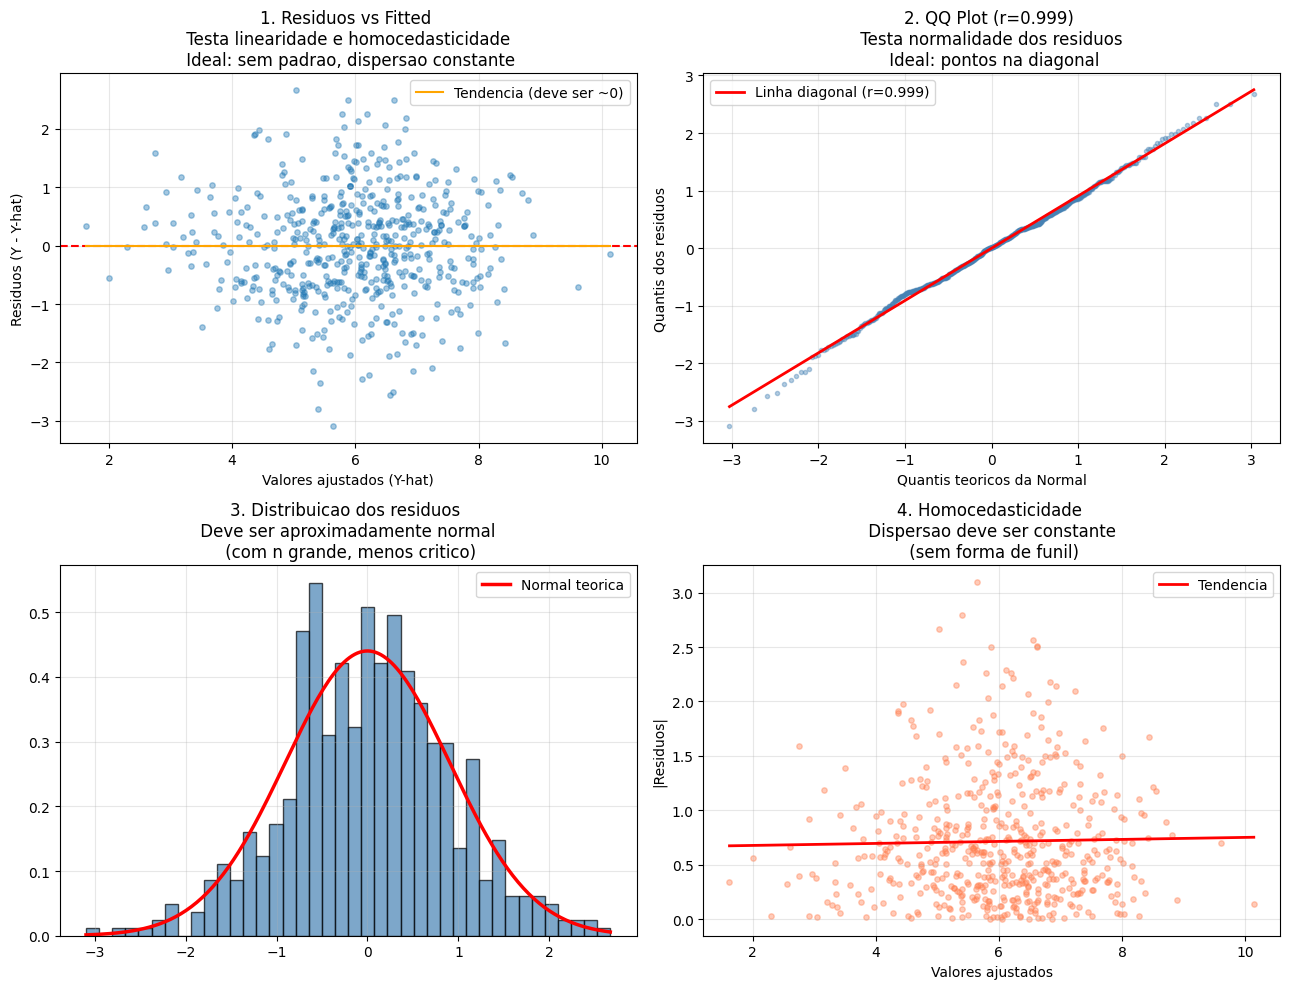


DIAGNOSTICO DAS PREMISSAS:
  Se grafico 1 tem padrao em U ou arco: VIOLACAO de linearidade
  Se grafico 1 tem formato de funil: VIOLACAO de homocedasticidade
  Se grafico 2 tem pontos longe da diagonal: VIOLACAO de normalidade
  (Com n grande: normalidade menos critica para predicao)


In [ ]:
# ── 3.2 METRICAS E ANALISE DE RESIDUOS ────────────────────────────────────────

# Calculando todas as metricas de avaliacao
mse  = mean_squared_error(y_te, y_pred)    # erro quadratico medio
rmse = np.sqrt(mse)                         # raiz do MSE (mesma unidade que NPS)
mae  = mean_absolute_error(y_te, y_pred)    # erro absoluto medio (robusto)
r2   = r2_score(y_te, y_pred)              # proporcao da variancia explicada
# R^2 ajustado: penaliza cada variavel adicional
n_te, p = len(y_te), len(X_cols)
r2_adj = 1 - (1-r2) * (n_te-1) / (n_te-p-1)

print("=== METRICAS DE AVALIACAO ===")
print()
print(f"  MSE:          {mse:.4f}  (em pontos de NPS ao quadrado)")
print(f"  RMSE:         {rmse:.4f}  (em pontos de NPS -- interpretavel)")
print(f"  MAE:          {mae:.4f}  (robusto a outliers)")
print(f"  R^2:          {r2:.4f}  -> modelo explica {r2*100:.1f}% da variancia do NPS")
print(f"  R^2 ajustado: {r2_adj:.4f}  (use este para comparar modelos com diff n de vars)")
print()
print("[!] PEGADINHAS SOBRE R^2:")
print("    R^2 NUNCA diminui quando voce adiciona mais variaveis (mesmo irrelevantes)")
print("    R^2 ajustado PODE diminuir -- penaliza variaveis sem poder explicativo")
print("    Sempre use R^2 ajustado para selecionar entre modelos com diff n de vars")

# Analise de residuos: verificando as premissas
residuos   = y_tr.values - modelo_ols.predict(X_tr)  # e_i = y_i - y_hat_i
y_fitted   = modelo_ols.predict(X_tr)                 # valores ajustados

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── Grafico 1: Residuos vs Fitted ──────────────────────────────────────────────
# Testa LINEARIDADE e HOMOCEDASTICIDADE
# Ideal: pontos espalhados aleatoriamente ao redor de 0, sem padrao
axes[0,0].scatter(y_fitted, residuos, alpha=0.4, s=15)
axes[0,0].axhline(0, color='red', lw=1.5, linestyle='--')
# Adicionando linha de tendencia para ver se ha padrao
z_resid = np.polyfit(y_fitted, residuos, 1)
axes[0,0].plot(sorted(y_fitted),
               np.polyval(z_resid, sorted(y_fitted)), 'orange', lw=1.5,
               label='Tendencia (deve ser ~0)')
axes[0,0].set_xlabel('Valores ajustados (Y-hat)')
axes[0,0].set_ylabel('Residuos (Y - Y-hat)')
axes[0,0].set_title('1. Residuos vs Fitted \n Testa linearidade e homocedasticidade \n Ideal: sem padrao, dispersao constante')
axes[0,0].legend()

# ── Grafico 2: QQ Plot ─────────────────────────────────────────────────────────
# Testa NORMALIDADE dos residuos
# Ideal: pontos na diagonal (residuos seguem distribuicao normal)
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[0,1].plot(osm, osr, 'o', alpha=0.4, ms=3, color='steelblue')
axes[0,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2,
               label=f'Linha diagonal (r={r:.3f})')
axes[0,1].set_xlabel('Quantis teoricos da Normal')
axes[0,1].set_ylabel('Quantis dos residuos')
axes[0,1].set_title(f'2. QQ Plot (r={r:.3f}) \n Testa normalidade dos residuos \n Ideal: pontos na diagonal')
axes[0,1].legend()

# ── Grafico 3: Histograma dos residuos ────────────────────────────────────────
# Complemento do QQ plot para verificar normalidade
axes[1,0].hist(residuos, bins=40, edgecolor='black', density=True, alpha=0.7,
               color='steelblue')
# Sobreposicao da Normal teorica com os parametros dos residuos
x_normal = np.linspace(residuos.min(), residuos.max(), 200)
axes[1,0].plot(x_normal,
               stats.norm.pdf(x_normal, residuos.mean(), residuos.std()),
               'r-', lw=2.5, label='Normal teorica')
axes[1,0].set_title('3. Distribuicao dos residuos \n Deve ser aproximadamente normal \n (com n grande, menos critico)')
axes[1,0].legend()

# ── Grafico 4: Residuos ao quadrado vs Fitted (homocedasticidade) ─────────────
axes[1,1].scatter(y_fitted, np.abs(residuos), alpha=0.4, s=15, color='coral')
z_abs = np.polyfit(y_fitted, np.abs(residuos), 1)
axes[1,1].plot(sorted(y_fitted),
               np.polyval(z_abs, sorted(y_fitted)),
               'r-', lw=2, label='Tendencia')
axes[1,1].set_xlabel('Valores ajustados')
axes[1,1].set_ylabel('|Residuos|')
axes[1,1].set_title('4. Homocedasticidade \n Dispersao deve ser constante \n (sem forma de funil)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print()
print("DIAGNOSTICO DAS PREMISSAS:")
print("  Se grafico 1 tem padrao em U ou arco: VIOLACAO de linearidade")
print("  Se grafico 1 tem formato de funil: VIOLACAO de homocedasticidade")
print("  Se grafico 2 tem pontos longe da diagonal: VIOLACAO de normalidade")
print("  (Com n grande: normalidade menos critica para predicao)")

In [ ]:
# ── 3.3 VIF: MULTICOLINEARIDADE ───────────────────────────────────────────────

# VIF (Variance Inflation Factor) mede o quanto a variancia de beta_j
# e inflada devido a multicolinearidade com as outras variaveis.
#
# Interpretacao:
# VIF_j = 1/(1 - R^2_j)
# onde R^2_j e o R^2 de regredir Xj nas outras variaveis X
#
# VIF = 1: Xj nao tem correlacao com as outras -> sem problema
# VIF = 5: Xj tem correlacao moderada -> atencao
# VIF = 10+: correlacao alta -> PROBLEMA

print("=== VIF: DETECTANDO MULTICOLINEARIDADE ===")
print()

X_train_num = X_tr.values  # converte DataFrame para array numpy (VIF precisa disso)

vif_data = pd.DataFrame({
    'variavel': X_cols,
    # VIF calculado para cada feature, controlando pelas demais
    'VIF': [variance_inflation_factor(X_train_num, i) for i in range(X_train_num.shape[1])]
})

# Classificando o nivel de problema
vif_data['status'] = vif_data['VIF'].apply(
    lambda v: 'OK' if v < 5 else ('ATENCAO' if v < 10 else 'PROBLEMA -- remover/combinar')
)

print(vif_data.to_string(index=False))
print()
print("O QUE FAZER com VIF alto:")
print("  1. Remover uma das variaveis correlacionadas")
print("  2. Combinar em uma variavel (ex: tempo_total = espera + resolucao)")
print("  3. Usar regularizacao (Ridge lida melhor com multicolinearidade)")
print()
print("[!] EFEITO DA MULTICOLINEARIDADE:")
print("    NAO afeta a qualidade das PREVISOES")
print("    AFETA a interpretacao dos COEFICIENTES (ficam instaveis)")
print("    Um mesmo dado pode dar coeficientes muito diferentes em amostras diferentes")
print()

# Demonstrando a instabilidade causada por multicolinearidade
np.random.seed(42)
n_demo = 200
X_original = np.random.normal(0, 1, n_demo)
X_correlacionado = X_original + np.random.normal(0, 0.1, n_demo)  # quase igual
Y_demo = 2*X_original + np.random.normal(0, 1, n_demo)

# Regressao so com X_original
coef_so_x = LinearRegression().fit(X_original.reshape(-1,1), Y_demo).coef_[0]
# Regressao com X_original e X_correlacionado (VIF muito alto)
X_ambos = np.column_stack([X_original, X_correlacionado])
coefs_ambos = LinearRegression().fit(X_ambos, Y_demo).coef_

print(f"Regressao so com X_original:              beta_X = {coef_so_x:.3f}")
print(f"Regressao com X_original + X_correlacion: beta_X = {coefs_ambos[0]:.3f}, "
      f"beta_Xc = {coefs_ambos[1]:.3f}")
print(f"Soma: {coefs_ambos[0]+coefs_ambos[1]:.3f} (proximo do {coef_so_x:.3f} correto)")
print("Nota: os coeficientes individuais ficam instáveis mas a soma se mantem")

=== VIF: DETECTANDO MULTICOLINEARIDADE ===

       variavel       VIF                       status
   tempo_espera  7.229627                      ATENCAO
tempo_resolucao  8.622364                      ATENCAO
     n_contatos  3.447880                           OK
  nivel_credito 12.109345 PROBLEMA -- remover/combinar
   tipo_produto  1.657697                           OK

O QUE FAZER com VIF alto:
  1. Remover uma das variaveis correlacionadas
  2. Combinar em uma variavel (ex: tempo_total = espera + resolucao)
  3. Usar regularizacao (Ridge lida melhor com multicolinearidade)

[!] EFEITO DA MULTICOLINEARIDADE:
    NAO afeta a qualidade das PREVISOES
    AFETA a interpretacao dos COEFICIENTES (ficam instaveis)
    Um mesmo dado pode dar coeficientes muito diferentes em amostras diferentes

Regressao so com X_original:              beta_X = 1.857
Regressao com X_original + X_correlacion: beta_X = 2.061, beta_Xc = -0.202
Soma: 1.859 (proximo do 1.857 correto)
Nota: os coeficientes indivi

In [ ]:
# ── 3.4 MAPE E QUANDO NAO USAR ────────────────────────────────────────────────

# MAPE = Mean Absolute Percentage Error
# Formula: MAPE = (1/n) * sum( |y_real - y_prev| / |y_real| ) * 100%
#
# PROBLEMA: quando y_real = 0, ocorre divisao por zero!
# Resultado: INDEFINIDO (nao e zero, e infinito ou NaN)

print("=== MAPE: QUANDO NAO USAR ===")
print()

casos_mape = [
    (10.0, 12.0, "valor normal"),
    (20.0, 18.0, "valor normal"),
    (0.0,   2.0, "PROBLEMA: divisao por zero!"),
    (50.0, 52.0, "valor normal"),
    (0.5,   0.8, "valor pequeno: MAPE exagera o erro"),
]

print(f"{'y_real':>8} {'y_prev':>8} {'|erro|':>8} {'MAPE_i':>12}  Observacao")
print("-"*65)
for yr, yp, obs in casos_mape:
    erro = abs(yr - yp)
    if yr == 0:
        print(f"{yr:>8.1f} {yp:>8.1f} {erro:>8.1f} {'INDEFINIDO':>12}  {obs}")
    else:
        mape_i = erro/abs(yr) * 100
        print(f"{yr:>8.1f} {yp:>8.1f} {erro:>8.1f} {mape_i:>11.1f}%  {obs}")

print()
print("[!] PEGADINHA DA PROVA (Q13 da prova real 2019):")
print("    y_pred = [0.1, 0.0, 0.2, 0.1]")
print("    y_true = [0.1, 0.0, 0.2, 0.1]")
print("    Afirmar que MAPE = 0 esta INCORRETO")
print("    MAPE e INDEFINIDO porque y_true[1] = 0 (divisao por zero)")
print()
print("QUANDO USAR CADA METRICA:")
print(f"  {'Metrica':<10} {'Outliers?':>10} {'y=0 ok?':>9} {'Unidade':>8}  Uso")
print("-"*65)
metricas_info = [
    ('MSE',   'Ruim',  'Sim', 'Y^2',  'Otimizacao (minimizar durante treino)'),
    ('RMSE',  'Ruim',  'Sim', 'Y',    'Reportar erro (mesma escala que Y)'),
    ('MAE',   'Bom',   'Sim', 'Y',    'Dados com outliers'),
    ('R^2',   'OK',    'Sim', '0-1',  'Proporcao variancia explicada'),
    ('MAPE',  'Ruim',  'NAO', '%',    'NUNCA com zeros, comparacao relativa'),
]
for m, out, zero, unid, uso in metricas_info:
    print(f"  {m:<10} {out:>10} {zero:>9} {unid:>8}  {uso}")

=== MAPE: QUANDO NAO USAR ===

  y_real   y_prev   |erro|       MAPE_i  Observacao
-----------------------------------------------------------------
    10.0     12.0      2.0        20.0%  valor normal
    20.0     18.0      2.0        10.0%  valor normal
     0.0      2.0      2.0   INDEFINIDO  PROBLEMA: divisao por zero!
    50.0     52.0      2.0         4.0%  valor normal
     0.5      0.8      0.3        60.0%  valor pequeno: MAPE exagera o erro

[!] PEGADINHA DA PROVA (Q13 da prova real 2019):
    y_pred = [0.1, 0.0, 0.2, 0.1]
    y_true = [0.1, 0.0, 0.2, 0.1]
    Afirmar que MAPE = 0 esta INCORRETO
    MAPE e INDEFINIDO porque y_true[1] = 0 (divisao por zero)

QUANDO USAR CADA METRICA:
  Metrica     Outliers?   y=0 ok?  Unidade  Uso
-----------------------------------------------------------------
  MSE              Ruim       Sim      Y^2  Otimizacao (minimizar durante treino)
  RMSE             Ruim       Sim        Y  Reportar erro (mesma escala que Y)
  MAE               Bo

In [ ]:
# ── QUESTOES DO MODULO 3 ──────────────────────────────────────────────────────

print("=" * 68)
print("QUESTOES DO MODULO 3")
print("=" * 68)
print("""
QUESTAO 1 (interpretacao de coeficiente):
  Modelo de regressao linear do NPS com resultado:
  beta_n_contatos = -0.42  (p-valor = 0.001)

  (a) Interprete o coeficiente para o gestor de atendimento.
  (b) O gestor conclui: 'entao devemos limitar ligacoes a no maximo 2.'
      Isso e uma conclusao valida?

QUESTAO 2 (R^2 e selecao de modelo):
  Modelo A: 4 variaveis, R^2 = 0.73, R^2 ajustado = 0.72
  Modelo B: 14 variaveis, R^2 = 0.76, R^2 ajustado = 0.70
  Qual voce escolhe e por que?

QUESTAO 3 (MAPE e metricas):
  Voce tem dados de volume de transacoes.
  Alguns clientes tem volume = R$0 em determinados meses.
  Por que voce NAO deve usar MAPE? Qual alternativa?
""")

print("GABARITOS:")
print("""
Q1:
  (a) 'Para cada contato adicional necessario para resolver o problema
      do cliente PJ, o NPS cai em media 0.42 pontos, MANTENDO tempo
      de espera, tempo de resolucao, nivel de credito e tipo de produto
      constantes. O resultado e estatisticamente significativo (p=0.001).'

      Para o diretor: 'Clientes que resolvem no primeiro contato dao NPS
      0.42 pontos mais alto por contato evitado -- isso representa impacto
      direto na retencao de carteira.'

  (b) NAO, essa conclusao pode nao ser valida.
      Correlacao nao e causalidade: clientes que ligam mais podem ja estar
      insatisfeitos por outras razoes (problemas de produto, credito negado).
      Limitar ligacoes pode simplesmente impedir que clientes insatisfeitos
      expressem suas queixas, sem resolver a causa raiz.
      Para tomar essa decisao: precisaria de um experimento controlado.

Q2: Modelo A (4 variaveis).
    R^2 NUNCA diminui com mais variaveis -- por isso B tem R^2 maior.
    R^2 ajustado penaliza a complexidade:
      Modelo A: R^2_adj = 0.72
      Modelo B: R^2_adj = 0.70  <- MENOR! As 10 variaveis extras nao compensam
    Alem disso: modelo mais simples, menos overfitting, mais interpretavel.
    Regra: use R^2 ajustado para comparar modelos com diff numero de variaveis.

Q3: MAPE divide por y_real. Quando y_real = 0: divisao por zero = indefinido.
    MAPE nao pode ser calculado. Alternativas:
    - MAE: robusto a outliers, mesma unidade de Y, funciona com zeros
    - RMSE: penaliza erros grandes, funciona com zeros
    - WMAPE: MAPE ponderado (soma |erros| / soma |y_real|) -- evita o problema

    Para dados de volume com zeros: MAE e a escolha mais segura.
""")

QUESTOES DO MODULO 3

QUESTAO 1 (interpretacao de coeficiente):
  Modelo de regressao linear do NPS com resultado:
  beta_n_contatos = -0.42  (p-valor = 0.001)

  (a) Interprete o coeficiente para o gestor de atendimento.
  (b) O gestor conclui: 'entao devemos limitar ligacoes a no maximo 2.'
      Isso e uma conclusao valida?

QUESTAO 2 (R^2 e selecao de modelo):
  Modelo A: 4 variaveis, R^2 = 0.73, R^2 ajustado = 0.72
  Modelo B: 14 variaveis, R^2 = 0.76, R^2 ajustado = 0.70
  Qual voce escolhe e por que?

QUESTAO 3 (MAPE e metricas):
  Voce tem dados de volume de transacoes.
  Alguns clientes tem volume = R$0 em determinados meses.
  Por que voce NAO deve usar MAPE? Qual alternativa?

GABARITOS:

Q1:
  (a) 'Para cada contato adicional necessario para resolver o problema
      do cliente PJ, o NPS cai em media 0.42 pontos, MANTENDO tempo
      de espera, tempo de resolucao, nivel de credito e tipo de produto
      constantes. O resultado e estatisticamente significativo (p=0.001).'



---
# MODULO 4 -- Classificacao e Regressao Logistica
## Prioridade: MUITO ALTA | ISLP Capitulo 4

---

## Por que nao regressao linear para classificar?

Problema concreto: voce quer prever se um CNPJ vai inadimplir (0) ou nao (1).

Se usar regressao linear:
- Para um CNPJ muito arriscado: modelo pode prever 1.8 (maior que 1!)
- Para um CNPJ muito seguro: modelo pode prever -0.3 (negativo!)
- Probabilidade nao pode ser < 0 ou > 1 -- sem sentido matematico

Solucao: comprimir qualquer valor real para o intervalo (0,1) usando a sigmoide.

---

## 4A. A funcao sigmoide -- por que ela funciona

```
sigmoid(z) = 1 / (1 + e^(-z))
```

Propriedades da sigmoide:
- Para z muito grande (positivo): sigmoid(z) -> 1
- Para z = 0: sigmoid(0) = 0.5
- Para z muito negativo: sigmoid(z) -> 0
- E monotonicamente crescente (quanto maior z, maior a probabilidade)

Na regressao logistica, z = beta_0 + beta_1*X1 + ... + beta_p*Xp
Entao: P(Y=1|X) = sigmoid(beta_0 + beta_1*X1 + ... + beta_p*Xp)

---

## 4B. Log-odds: o que o modelo realmente faz

Tomando o logaritmo da razao de probabilidades:

```
log( P(Y=1) / P(Y=0) ) = beta_0 + beta_1*X1 + ... + beta_p*Xp
```

O lado esquerdo e chamado de log-odds (ou logit).
O modelo e LINEAR nos log-odds, mas nao em P diretamente.

**Odds:** razao P(evento) / P(nao-evento)
- Se P(inadimplir) = 0.20, entao odds = 0.20/0.80 = 0.25
- Se P(inadimplir) = 0.50, entao odds = 0.50/0.50 = 1.0
- Se P(inadimplir) = 0.80, entao odds = 0.80/0.20 = 4.0

**Odds Ratio (e^beta_j):** quanto as odds se multiplicam para cada unidade de Xj.
- Se beta_atraso = 0.8, entao OR = e^0.8 = 2.23
- Interpretacao: 'empresa com atraso tem odds de inadimplir 2.23x maiores'

[!] Odds Ratio != Razao de Probabilidades! Odds=2 significa P=0.667, nao P=2!

---

## 4C. Matriz de confusao e TODOS os termos

```
                     | Previsto 0 (negativo) | Previsto 1 (positivo)
Real 0 (nao inadimpl)| TN (True Negative)    | FP (False Positive)
Real 1 (inadimpliu)  | FN (False Negative)   | TP (True Positive)
```

**Definicao de cada celula:**
- **TP (True Positive):** modelo previu 1 E era 1. Acerto no positivo.
  Exemplo: modelo disse 'vai inadimplir' e o cliente realmente inadimpliu.

- **TN (True Negative):** modelo previu 0 E era 0. Acerto no negativo.
  Exemplo: modelo disse 'nao vai inadimplir' e o cliente nao inadimpliu.

- **FP (False Positive):** modelo previu 1 mas era 0. Alarme falso.
  Exemplo: modelo disse 'vai inadimplir' mas o cliente pagou certinho.
  Consequencia: nega credito para bom pagador.

- **FN (False Negative):** modelo previu 0 mas era 1. Miss, erro grave.
  Exemplo: modelo disse 'nao vai inadimplir' mas o cliente deu calote.
  Consequencia: aprova credito para mau pagador.

**Formulas das metricas derivadas:**
- **Acuracia:** (TP+TN) / (TP+TN+FP+FN) -- % de acertos geral
- **Precision:** TP / (TP+FP) -- dos que previ como positivo, quantos sao?
- **Recall (TPR):** TP / (TP+FN) -- dos positivos reais, quantos capturei?
- **F1:** 2*P*R / (P+R) -- media harmonica de P e R
- **FPR:** FP / (FP+TN) -- taxa de alarme falso

---

## 4D. ROC Curve e AUC -- interpretacao completa

A curva ROC plota TPR (recall) vs FPR para todos os thresholds possiveis.
- Ponto (0,0): threshold=1, nao prevê nada como positivo
- Ponto (1,1): threshold=0, prevê tudo como positivo
- Diagonal: modelo aleatorio (AUC=0.5)
- Curva ideal: vai ate o canto superior esquerdo (TPR=1, FPR=0)

AUC (Area Under the ROC Curve):
- AUC = 0.5: modelo aleatorio, inutil
- AUC = 0.7: discriminacao aceitavel
- AUC = 0.8: boa discriminacao
- AUC > 0.95: SUSPEITO -- provavelmente ha data leakage

---

## 4E. Threshold e a logica de negocio

O modelo retorna probabilidade (0 a 1). Voce escolhe o threshold para classificar.
Default = 0.5, mas raramente e o otimo!

**Como escolher:**
- Se FN e mais caro (fraude, churn): threshold BAIXO -> mais recall
- Se FP e mais caro (credito negado erroneamente): threshold ALTO -> mais precision
- Formula: minimize (FP * custo_FP + FN * custo_FN)


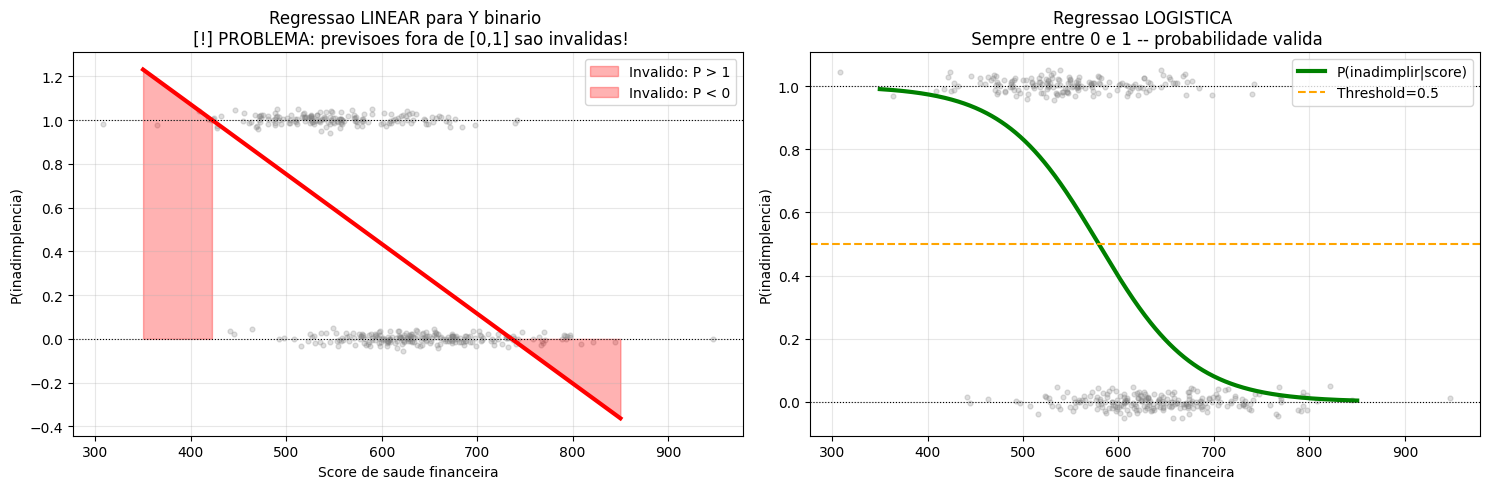

ODDS RATIO -- COMO INTERPRETAR COEFICIENTES DA LOGISTICA:

  beta_j   OR = e^beta  Interpretacao
-----------------------------------------------------------------
    -1.5         0.223  odds CAEM 78% por unidade de X
    -0.8         0.449  odds CAEM 55% por unidade de X
    -0.3         0.741  odds CAEM 26% por unidade de X
     0.0         1.000  sem efeito das odds
     0.3         1.350  odds SOBEM 35% por unidade de X
     0.8         2.226  odds SOBEM 123% por unidade de X
     1.5         4.482  odds SOBEM 348% por unidade de X

[!] ODDS RATIO != RAZAO DE PROBABILIDADES:
    OR=2.0 nao significa que a probabilidade dobra!
    Se P_base = 0.10, OR=2 -> P_novo = 0.18 (nao 0.20)
    Odds: 0.10/0.90 = 0.111 -> * 2 = 0.222 -> P = 0.222/1.222 = 0.18


In [ ]:
# ── 4.1 POR QUE NAO REGRESSAO LINEAR: DEMONSTRACAO VISUAL ──────────────────────

np.random.seed(42)
n4 = 400

# Criando dados de CNPJs com score de saude financeira
# Score baixo -> mais propenso a inadimplir
score_saude = np.random.normal(600, 90, n4)  # score 300-900

# Probabilidade real de inadimplencia: decresce com o score
prob_real = 1 / (1 + np.exp((score_saude - 575) / 50))

# Y binario: 0 (pagou) ou 1 (inadimpliu)
inadimpliu = np.random.binomial(1, prob_real)

# Preparando para sklearn
X4 = score_saude.reshape(-1, 1)
X_plot4 = np.linspace(350, 850, 500).reshape(-1, 1)

# Treinando os dois modelos
modelo_linear4 = LinearRegression().fit(X4, inadimpliu)
modelo_logist4 = LogisticRegression().fit(X4, inadimpliu)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Grafico 1: Regressao Linear para Y binario ────────────────────────────────
# Mostrando o problema: previsoes fora de [0,1]
previsoes_linear = modelo_linear4.predict(X_plot4)
n_invalidos = ((previsoes_linear < 0) | (previsoes_linear > 1)).sum()

axes[0].scatter(score_saude, inadimpliu + np.random.normal(0, 0.02, n4),
                alpha=0.25, s=12, color='gray')
axes[0].plot(X_plot4, previsoes_linear, 'r-', lw=3)
# Destacando as regioes invalidas
axes[0].fill_between(X_plot4.ravel(), previsoes_linear,
                     where=previsoes_linear > 1,
                     color='red', alpha=0.3, label=f'Invalido: P > 1')
axes[0].fill_between(X_plot4.ravel(), previsoes_linear,
                     where=previsoes_linear < 0,
                     color='red', alpha=0.3, label=f'Invalido: P < 0')
axes[0].axhline(0, color='black', lw=0.8, linestyle=':')
axes[0].axhline(1, color='black', lw=0.8, linestyle=':')
axes[0].set_xlabel('Score de saude financeira')
axes[0].set_ylabel('P(inadimplencia)')
axes[0].set_title('Regressao LINEAR para Y binario \n [!] PROBLEMA: previsoes fora de [0,1] sao invalidas!')
axes[0].legend()

# ── Grafico 2: Regressao Logistica ────────────────────────────────────────────
# Sempre entre 0 e 1: probabilidade valida
prob_logistica = modelo_logist4.predict_proba(X_plot4)[:,1]

axes[1].scatter(score_saude, inadimpliu + np.random.normal(0, 0.02, n4),
                alpha=0.25, s=12, color='gray')
axes[1].plot(X_plot4, prob_logistica, 'g-', lw=3, label='P(inadimplir|score)')
axes[1].axhline(0.5, color='orange', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[1].axhline(0, color='black', lw=0.8, linestyle=':')
axes[1].axhline(1, color='black', lw=0.8, linestyle=':')
axes[1].set_xlabel('Score de saude financeira')
axes[1].set_ylabel('P(inadimplencia)')
axes[1].set_title('Regressao LOGISTICA \n Sempre entre 0 e 1 -- probabilidade valida')
axes[1].legend()

plt.tight_layout()
plt.show()

print("ODDS RATIO -- COMO INTERPRETAR COEFICIENTES DA LOGISTICA:")
print()
print(f"{'beta_j':>8}  {'OR = e^beta':>12}  Interpretacao")
print("-"*65)
for b in [-1.5, -0.8, -0.3, 0.0, 0.3, 0.8, 1.5]:
    OR = np.exp(b)
    if abs(b) < 0.01:
        descricao = "sem efeito das odds"
    elif OR < 1:
        descricao = f"odds CAEM {(1-OR)*100:.0f}% por unidade de X"
    else:
        descricao = f"odds SOBEM {(OR-1)*100:.0f}% por unidade de X"
    print(f"{b:>8.1f}  {OR:>12.3f}  {descricao}")

print()
print("[!] ODDS RATIO != RAZAO DE PROBABILIDADES:")
print("    OR=2.0 nao significa que a probabilidade dobra!")
print("    Se P_base = 0.10, OR=2 -> P_novo = 0.18 (nao 0.20)")
print("    Odds: 0.10/0.90 = 0.111 -> * 2 = 0.222 -> P = 0.222/1.222 = 0.18")

In [ ]:
# ── 4.2 MATRIZ DE CONFUSAO E TODAS AS METRICAS ────────────────────────────────

np.random.seed(42)
n4b = 3000

# Simulando um modelo de deteccao de detratores do NPS
# Base desbalanceada: 20% de detratores (tipico em contexto bancario)
y_real = np.random.binomial(1, 0.20, n4b)  # 20% de detratores

# Probabilidades previstas pelo modelo (modelo razoavel mas nao perfeito)
# Detratores reais tendem a ter probabilidade maior, nao-detratores menor
proba_prev = np.where(
    y_real == 1,
    np.random.beta(7, 3, n4b),  # detratores: beta(7,3) concentrado perto de 1
    np.random.beta(3, 7, n4b)   # promotores: beta(3,7) concentrado perto de 0
)

# Aplicando threshold de 0.5 para classificar
threshold = 0.5
y_pred = (proba_prev >= threshold).astype(int)

# Calculando a matriz de confusao
cm = confusion_matrix(y_real, y_pred)
TP = cm[1,1]  # previu detrator e era detrator
TN = cm[0,0]  # previu promotor/neutro e era promotor/neutro
FP = cm[0,1]  # previu detrator mas era promotor/neutro (ALARME FALSO)
FN = cm[1,0]  # previu promotor mas era detrator (MISS -- mais grave!)

print("=== MATRIZ DE CONFUSAO ===")
print()
print(f"               | Previsto 0 (nao detrator) | Previsto 1 (detrator)")
print(f"---------------+--------------------------+---------------------")
print(f"Real 0 (nao)   |  TN = {TN:5d}              |  FP = {FP:5d}")
print(f"               |  Acertou o negativo       |  ALARME FALSO")
print(f"               |  (cliente ok previsto ok) |  (ok previsto como prob)")
print(f"---------------+--------------------------+---------------------")
print(f"Real 1 (detrat)|  FN = {FN:5d}              |  TP = {TP:5d}")
print(f"               |  MISS -- mais grave!      |  Acertou o positivo")
print(f"               |  (detrator previsto ok)   |  (detrator previsto)")
print()

# Calculando todas as metricas manualmente
acuracia  = (TP+TN) / (TP+TN+FP+FN)
precision = TP / (TP+FP) if (TP+FP) > 0 else 0
recall    = TP / (TP+FN) if (TP+FN) > 0 else 0  # = TPR = Sensibilidade
f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
fpr       = FP / (FP+TN)  # taxa de alarme falso
auc       = roc_auc_score(y_real, proba_prev)
ll        = log_loss(y_real, proba_prev)

print("=== METRICAS CALCULADAS MANUALMENTE ===")
print()
metricas = [
    ("Acuracia",  "(TP+TN)/total",   acuracia,  "% de acertos geral"),
    ("Precision", "TP/(TP+FP)",      precision, "dos previstos detrator, quantos sao?"),
    ("Recall/TPR","TP/(TP+FN)",      recall,    "dos detratores reais, quantos capturei?"),
    ("F1 Score",  "2*P*R/(P+R)",     f1,        "media harmonica P e R"),
    ("FPR",       "FP/(FP+TN)",      fpr,       "taxa de alarme falso"),
    ("ROC-AUC",   "area curva ROC",  auc,       "discriminacao geral do modelo"),
    ("Log Loss",  "-sum(y*log(p))",  ll,        "qualidade das probabilidades"),
]
for nome, formula, valor, desc in metricas:
    print(f"  {nome:<12}: {formula:<20} = {valor:.4f}  | {desc}")

print()
acur_idiota = (y_real==0).mean()
print(f"[!] ARMADILHA DA ACURACIA:")
print(f"    Base tem {y_real.mean()*100:.0f}% de detratores")
print(f"    Modelo idiota (preve SEMPRE 0): acuracia = {acur_idiota:.3f}")
print(f"    Nosso modelo real:               acuracia = {acuracia:.3f}")
print(f"    Ganho real sobre o idiota: apenas {(acuracia-acur_idiota)*100:.1f}pp")
print(f"    -> Use AUC ou F1, nao acuracia, com base desbalanceada!")
print()
print("[!] MAE E METRICA DE REGRESSAO:")
print("    MAE = mean(|y_real - y_prev|) -- funciona so com Y numerico continuo")
print("    Para classificacao: use Precision, Recall, F1, AUC, Log Loss")
print("    Erro classico de prova: usar MAE para classificacao")

=== MATRIZ DE CONFUSAO ===

               | Previsto 0 (nao detrator) | Previsto 1 (detrator)
---------------+--------------------------+---------------------
Real 0 (nao)   |  TN =  2175              |  FP =   217
               |  Acertou o negativo       |  ALARME FALSO
               |  (cliente ok previsto ok) |  (ok previsto como prob)
---------------+--------------------------+---------------------
Real 1 (detrat)|  FN =    47              |  TP =   561
               |  MISS -- mais grave!      |  Acertou o positivo
               |  (detrator previsto ok)   |  (detrator previsto)

=== METRICAS CALCULADAS MANUALMENTE ===

  Acuracia    : (TP+TN)/total        = 0.9120  | % de acertos geral
  Precision   : TP/(TP+FP)           = 0.7211  | dos previstos detrator, quantos sao?
  Recall/TPR  : TP/(TP+FN)           = 0.9227  | dos detratores reais, quantos capturei?
  F1 Score    : 2*P*R/(P+R)          = 0.8095  | media harmonica P e R
  FPR         : FP/(FP+TN)           = 0.0907  

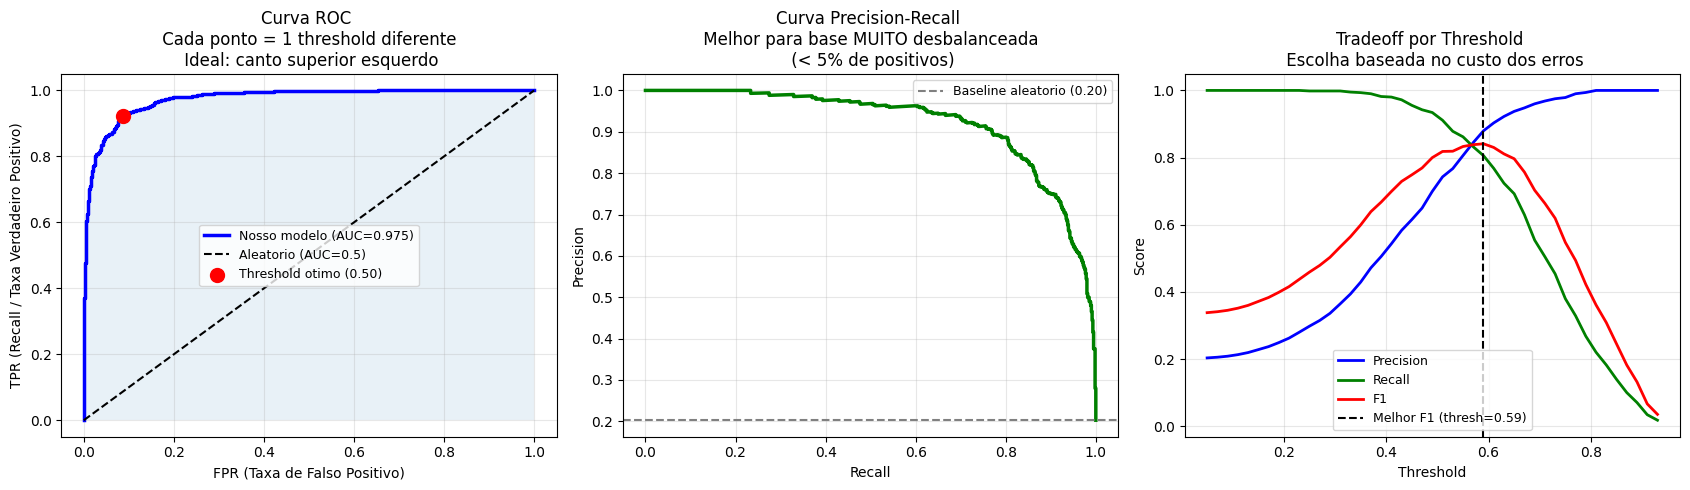

COMO ESCOLHER O THRESHOLD -- LOGICA DE NEGOCIO:

  Threshold BAIXO -> mais recall, mais FP:
    Quando: FN e muito mais caro que FP
    Exemplo: deteccao de fraude -- nao perder fraude nenhuma
    Aceita: bloquear mais transacoes legitimas (FP)

  Threshold ALTO -> mais precision, mais FN:
    Quando: FP e muito mais caro que FN
    Exemplo: campanha cara (ligacao) -- so abordar quem vai aceitar
    Aceita: perder alguns clientes propensos (FN)

  Formula: minimize (FP * custo_FP + FN * custo_FN)
    Ex: FP custa R$50 (ligacao desperdicada), FN custa R$500 (perda de venda)
    Neste caso: prefira baixar o threshold (aceitar mais FP, evitar FN)


In [ ]:
# ── 4.3 CURVAS ROC, PRECISION-RECALL E TRADEOFF DE THRESHOLD ─────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Curva ROC ─────────────────────────────────────────────────────────────────
# Plota TPR (recall) vs FPR para todos os thresholds possiveis
# Cada ponto da curva corresponde a um threshold diferente
fpr_curve, tpr_curve, thresholds_roc = roc_curve(y_real, proba_prev)
auc_valor = roc_auc_score(y_real, proba_prev)

# Encontrando o ponto otimo (maximiza TPR - FPR, metodo de Youden)
idx_otimo = np.argmax(tpr_curve - fpr_curve)
thresh_otimo = thresholds_roc[idx_otimo]

axes[0].plot(fpr_curve, tpr_curve, 'b-', lw=2.5,
             label=f'Nosso modelo (AUC={auc_valor:.3f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1.5, label='Aleatorio (AUC=0.5)')
axes[0].fill_between(fpr_curve, tpr_curve, alpha=0.1)
axes[0].scatter([fpr_curve[idx_otimo]], [tpr_curve[idx_otimo]],
                color='red', s=100, zorder=5,
                label=f'Threshold otimo ({thresh_otimo:.2f})')
axes[0].set_xlabel('FPR (Taxa de Falso Positivo)')
axes[0].set_ylabel('TPR (Recall / Taxa Verdadeiro Positivo)')
axes[0].set_title('Curva ROC \n Cada ponto = 1 threshold diferente \n Ideal: canto superior esquerdo')
axes[0].legend(fontsize=9)

# ── Curva Precision-Recall ─────────────────────────────────────────────────────
# Mais informativa que ROC quando a base e muito desbalanceada
prec_curve, rec_curve, _ = precision_recall_curve(y_real, proba_prev)

axes[1].plot(rec_curve, prec_curve, 'g-', lw=2.5)
axes[1].axhline(y_real.mean(), color='gray', linestyle='--',
                label=f'Baseline aleatorio ({y_real.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall \n Melhor para base MUITO desbalanceada \n (< 5% de positivos)')
axes[1].legend(fontsize=9)

# ── Tradeoff de threshold ──────────────────────────────────────────────────────
# Mostrando como Precision e Recall variam com o threshold
threshs_teste = np.arange(0.05, 0.95, 0.02)
precs_t, recs_t, f1s_t = [], [], []

for t in threshs_teste:
    yp = (proba_prev >= t).astype(int)
    tp_ = ((yp==1)&(y_real==1)).sum()
    fp_ = ((yp==1)&(y_real==0)).sum()
    fn_ = ((yp==0)&(y_real==1)).sum()
    p_  = tp_/(tp_+fp_) if (tp_+fp_) > 0 else 0
    r_  = tp_/(tp_+fn_) if (tp_+fn_) > 0 else 0
    f_  = 2*p_*r_/(p_+r_) if (p_+r_) > 0 else 0
    precs_t.append(p_); recs_t.append(r_); f1s_t.append(f_)

best_f1_idx = np.argmax(f1s_t)
axes[2].plot(threshs_teste, precs_t, 'b-', lw=2, label='Precision')
axes[2].plot(threshs_teste, recs_t,  'g-', lw=2, label='Recall')
axes[2].plot(threshs_teste, f1s_t,   'r-', lw=2, label='F1')
axes[2].axvline(threshs_teste[best_f1_idx], color='black', linestyle='--',
                label=f'Melhor F1 (thresh={threshs_teste[best_f1_idx]:.2f})')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Tradeoff por Threshold \n Escolha baseada no custo dos erros')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("COMO ESCOLHER O THRESHOLD -- LOGICA DE NEGOCIO:")
print()
print("  Threshold BAIXO -> mais recall, mais FP:")
print("    Quando: FN e muito mais caro que FP")
print("    Exemplo: deteccao de fraude -- nao perder fraude nenhuma")
print("    Aceita: bloquear mais transacoes legitimas (FP)")
print()
print("  Threshold ALTO -> mais precision, mais FN:")
print("    Quando: FP e muito mais caro que FN")
print("    Exemplo: campanha cara (ligacao) -- so abordar quem vai aceitar")
print("    Aceita: perder alguns clientes propensos (FN)")
print()
print("  Formula: minimize (FP * custo_FP + FN * custo_FN)")
print("    Ex: FP custa R$50 (ligacao desperdicada), FN custa R$500 (perda de venda)")
print("    Neste caso: prefira baixar o threshold (aceitar mais FP, evitar FN)")

In [ ]:
# ── QUESTOES DO MODULO 4 ──────────────────────────────────────────────────────

print("=" * 68)
print("QUESTOES DO MODULO 4")
print("=" * 68)

# Questao 1: calculo manual
print("""
QUESTAO 1 (calculo manual -- nivel prova):
  Modelo de deteccao de inadimplencia. Resultados no conjunto de teste:
  TP = 85, TN = 820, FP = 45, FN = 150

  (a) Calcule: Acuracia, Precision, Recall e F1.
  (b) O Recall de 36.2% e aceitavel para um modelo de credito? Explique.
  (c) O que significa um FN neste contexto?
""")

TP_q = 85; TN_q = 820; FP_q = 45; FN_q = 150
total_q = TP_q + TN_q + FP_q + FN_q
acc_q  = (TP_q+TN_q)/total_q
prec_q = TP_q/(TP_q+FP_q)
rec_q  = TP_q/(TP_q+FN_q)
f1_q   = 2*prec_q*rec_q/(prec_q+rec_q)

print("GABARITOS:")
print(f"""
Q1:
  (a) Total = {total_q}
      Acuracia  = ({TP_q}+{TN_q})/{total_q} = {acc_q:.4f}
      Precision = {TP_q}/({TP_q}+{FP_q})    = {prec_q:.4f}
      Recall    = {TP_q}/({TP_q}+{FN_q})    = {rec_q:.4f}
      F1        = 2*{prec_q:.3f}*{rec_q:.3f}/({prec_q:.3f}+{rec_q:.3f}) = {f1_q:.4f}

  (b) Recall de {rec_q*100:.1f}% PODE NAO ser aceitavel para credito.
      Significa que o modelo PERDEU {FN_q} inadimplentes (nao detectou).
      Esses {FN_q} clientes receberam credito e provavelmente geraram calote.
      Depende do custo relativo: se cada inadimplente representa prejuizo
      alto, o modelo precisa de recall maior (threshold menor).
      Verificar: qual e o custo medio por inadimplente vs custo de negar
      credito para um bom pagador (FP)?

  (c) FN = False Negative = {FN_q} casos.
      Modelo previu que o cliente NAO ia inadimplir, mas ele INADIMPLIU.
      Consequencia: credito foi aprovado para quem nao devia ter recebido.
      E o erro mais grave em modelos de credito: gera inadimplencia direta.
      FP seria menos grave: negar credito a bom pagador (perda de receita,
      mas sem inadimplencia).
""")

print("""
QUESTAO 2 (conceitual):
  AUC = 0.96 no teste de modelo de churn.
  O que voce investigaria antes de colocar em producao?

QUESTAO 3 (tradeoff):
  Modelo de deteccao de churn com:
  Precision = 0.88, Recall = 0.22

  (a) O que isso significa em linguagem de negocio?
  (b) Em qual situacao esse modelo seria ou nao seria adequado?
""")

print("""
Q2: AUC=0.96 e suspeita de DATA LEAKAGE.
    Verificar:
    1. Feature importance: alguma variavel domina (>50%) inesperadamente?
    2. Existe alguma variavel que so existe DEPOIS do churn?
       Ex: 'data_cancelamento', 'motivo_saida', 'score_final_pre_saida'
    3. Testar em janela temporal futura: leakage colapsa completamente
       (AUC vai para 0.5-0.6), overfitting degrada gradualmente
    4. Verificar se o split treino/teste foi temporal ou aleatorio

    Em producao: nunca usar feature que so existe apos o evento.

Q3:
  (a) Linguagem de negocio:
      Precision=0.88: 'De cada 100 clientes que o modelo sinaliza como
      propensos ao churn, 88 realmente estao em risco.' (poucos FP)
      Recall=0.22: 'O modelo identifica apenas 22% de todos os clientes
      que vao churnar.' (muitos FN -- perde 78% dos casos reais)

  (b) ADEQUADO quando:
      - A acao de retencao e muito cara (ligacao de gerente dedicado)
      - Voce prefere agir em poucos casos com alta certeza
      - O custo de FP (acionar cliente que nao ia churnar) e alto

      NAO ADEQUADO quando:
      - Voce precisa identificar a maioria dos churners (ex: campanha em massa barata)
      - O custo de FN (perder o cliente) e muito alto
      - Solucao: baixar o threshold para aumentar o recall
""")

QUESTOES DO MODULO 4

QUESTAO 1 (calculo manual -- nivel prova):
  Modelo de deteccao de inadimplencia. Resultados no conjunto de teste:
  TP = 85, TN = 820, FP = 45, FN = 150

  (a) Calcule: Acuracia, Precision, Recall e F1.
  (b) O Recall de 36.2% e aceitavel para um modelo de credito? Explique.
  (c) O que significa um FN neste contexto?

GABARITOS:

Q1:
  (a) Total = 1100
      Acuracia  = (85+820)/1100 = 0.8227
      Precision = 85/(85+45)    = 0.6538
      Recall    = 85/(85+150)    = 0.3617
      F1        = 2*0.654*0.362/(0.654+0.362) = 0.4658

  (b) Recall de 36.2% PODE NAO ser aceitavel para credito.
      Significa que o modelo PERDEU 150 inadimplentes (nao detectou).
      Esses 150 clientes receberam credito e provavelmente geraram calote.
      Depende do custo relativo: se cada inadimplente representa prejuizo
      alto, o modelo precisa de recall maior (threshold menor).
      Verificar: qual e o custo medio por inadimplente vs custo de negar
      credito para um bom 